In [1]:
import pandas as pd
import numpy as np

import os, json, yaml, random, asyncio, math, time
from datetime import datetime
from tqdm import tqdm
from tqdm.asyncio import tqdm_asyncio
from typing import List, Dict, Any
from itertools import product

from opensearchpy.helpers import scan as opensearch_scan
from elasticsearch.helpers import scan as elasticsearch_scan, bulk as  es_bulk
from weaviate.classes.data import DataObject
from openai import AsyncOpenAI

import matplotlib.pyplot as plt
import seaborn as sns

from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain.retrievers import EnsembleRetriever
from langchain_weaviate import WeaviateVectorStore

from utils.rag_prep_upload_kb import run_upload_pipeline

from utils.rag_utils_open import (get_opensearch_client, 
                                    create_open_schema, 
                                    build_opensearch_index,
                                    get_opensearch_vectorstore)

from utils.rag_utils_es import (get_es_client, 
                                    create_es_schema, 
                                    build_elasticsearch_index,

                                    get_es_vectorstore)
from utils.rag_utils_wv import get_weaviate_client, create_weaviate_schema

from utils.rag_retriever import (
    OpenSearchTextRetriever,
    ElasticsearchTextRetriever,
    WeaviateHybridRetriever,
    VectorStoreAdapterRetriever
)
from dotenv import load_dotenv
load_dotenv()

with open('config/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

EMBEDDING_DIM = config['openai']['embeddings']['dim'][1]
EMBEDDING_MODEL = config['openai']['embeddings']['models'][1]

OPENSEARCH_INDEX_NAME = config['aws']['opensearch']['kgs_index']
ELASTICSEARCH_INDEX_NAME = config['elasticsearch']['kgs_index']
WEAVIATE_COLLECTION_NAME = config['weaviate']['kgs_index']

RETRIEVER_K = 30
BM_ALPHA = 1e-6
SAMPLE_SIZE = 1000

# 평가 기본 경로
BASE_PATH = "eval/"

# 샘플 데이터 파일 경로 (테스트 인덱스 업로드용)
OPENSEARCH_SAMPLE_PATH = os.path.join(BASE_PATH, "db_paraphrase/os_orig.jsonl")
ELASTICSEARCH_SAMPLE_PATH = os.path.join(BASE_PATH, "db_paraphrase/es_orig.jsonl")
WEAVIATE_SAMPLE_PATH = os.path.join(BASE_PATH, "db_paraphrase/wv_orig.jsonl")

# 패러프레이즈 파일 경로 
OPENSEARCH_TEST_PATH = os.path.join(BASE_PATH, "db_paraphrase/os_para.jsonl")
ELASTICSEARCH_TEST_PATH = os.path.join(BASE_PATH, "db_paraphrase/es_para.jsonl")
WEAVIATE_TEST_PATH = os.path.join(BASE_PATH, "db_paraphrase/wv_test.jsonl")

# 클라이언트 초기화
os_client = get_opensearch_client()
es_client = get_es_client()
wv_client = get_weaviate_client()
openai_client = AsyncOpenAI()

# 그래프 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

if os.name == 'nt':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# 동시 실행 최대 개수 (DB 부하 방지)
SEMAPHORE = asyncio.Semaphore(5)  

# =========================================================
# 데이터 추출 및 저장 함수
# =========================================================
def ensure_dir(path: str):
    """ 폴더 확인 후 없으면 만들기 """
    directory = os.path.dirname(path)
    if directory and not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)

def save_to_jsonl(data: List[Dict], filename: str):
    """ iterable 데이터 하나씩 jsonl 파일에 입력 """
    ensure_dir(filename)
    with open(filename, 'w', encoding='utf-8') as f: # 파일열고
        for entry in data:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n") # 데이터 jsonl로 바꿔서 저장
    print(f"✅ 저장 완료: {filename} ({len(data)}건)")

def make_index_name(base: str, db: str, p: dict) -> str:
    """ 파라미터를 인코딩하여 유니크한 인덱스 이름 생성 """
    k1_str = str(p['k1']).replace('.', '_')
    b_str = str(p['b']).replace('.', '_')
    return f"{base}_{db}_k1_{k1_str}_b_{b_str}_m_{p['m']}_efs_{p['ef_search']}_efc_{p['ef_construction']}"

def build_index_for_params(db: str, index_name: str, p: dict, properties: Any):
    """ DB별 인덱스 생성 로직 """
    try:
        if db == "opensearch":
            client = os_client
            body = create_open_schema(
                embedding_dim=EMBEDDING_DIM, k1=p['k1'], b=p['b'], M=p['m'], 
                EFC=p['ef_construction'], EFS=p['ef_search'], metadata=properties
            )
            build_opensearch_index(client, index_name, body)

        elif db == "elasticsearch":
            client = es_client
            body = create_es_schema(
                embedding_dim=EMBEDDING_DIM, k1=p['k1'], b=p['b'], M=p['m'], 
                EFC=p['ef_construction'], metadata=properties
            )
            build_elasticsearch_index(client, index_name, body)

        elif db == "weaviate":
            client = wv_client
            create_weaviate_schema(
                client=client, index_name=index_name, properties=properties,
                efc=p['ef_construction'], m=p['m'], efs=p['ef_search'], k1=p['k1'], b=p['b']
            )
    except Exception as e:
        raise e
    return client

def sample_queries(gt_dict: dict, n: int = SAMPLE_SIZE):
    """
    gt_dict: { query(str) : set(answer_ids) }
    """
    items = list(gt_dict.items())
    if len(items) <= n:
        return items
    return random.sample(items, n)

def compute_ndcg_at_k(retrieved_docs, gt_ids, k: int) -> float:
    """
    retrieved_docs: List[Document], metadata["_id"]에 문서 id 들어있다고 가정
    gt_ids: 정답 id set
    """
    if not gt_ids:
        return 0.0

    # DCG 계산
    dcg = 0.0
    for rank, doc in enumerate(retrieved_docs[:k]):
        doc_id = doc.metadata.get("_id") or doc.metadata.get("uuid")
        rel = 1.0 if doc_id in gt_ids else 0.0
        if rel > 0:
            dcg += rel / math.log2(rank + 2)  # rank 0 -> log2(2) = 1

    # IDCG (정답 문서들이 전부 상위에 있다고 가정)
    ideal_hits = min(len(gt_ids), k)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(ideal_hits))

    return (dcg / idcg) if idcg > 0 else 0.0

def compute_mrr_at_k(retrieved_ids: list[str], gt_ids: list[str] | set[str], k: int) -> float:
    """
    MRR@k (Mean Reciprocal Rank) 계산 함수
    - retrieved_ids: 검색된 문서 ID 리스트 (순위순)
    - gt_ids: 정답 문서 ID 리스트 또는 집합
    - k: 상위 k개만 평가
    """
    if not gt_ids: 
        return 0.0
    
    # gt_ids가 리스트면 set으로 변환 (검색 속도 향상)
    gt_ids_set = set(gt_ids) if isinstance(gt_ids, list) else gt_ids
    
    # k개까지만 확인
    for rank, doc_id in enumerate(retrieved_ids[:k]):
        if doc_id in gt_ids_set:
            # 첫 번째 정답을 찾으면 그 순위의 역수(1/rank)를 반환하고 종료
            # rank는 0부터 시작하므로 +1 해줌
            return 1.0 / (rank + 1)
            
    # k개 안에 정답이 없으면 0점
    return 0.0

DB_SCHEMAS = {
    "opensearch": {
        "question": {"type": "text", "analyzer": "standard"}, 
        "question_morph": {"type": "text", "analyzer": "korean_nori"}, 
        "text_morph": {"type": "text", "analyzer": "korean_nori"},
        "university": {"type": "keyword"},
        "year": {"type": "integer"},
        "category1": {"type": "keyword"},
        "category2": {"type": "keyword"},
        "category3": {"type": "keyword"},
    },
    "elasticsearch": {
        "question": {"type": "text", "analyzer": "standard"}, 
        "question_morph": {"type": "text", "analyzer": "kiwi_ws"}, 
        "text_morph": {"type": "text", "analyzer": "kiwi_ws"},
        "university": {"type": "keyword"},
        "year": {"type": "integer"},
        "category1": {"type": "keyword"},
        "category2": {"type": "keyword"},
        "category3": {"type": "keyword"},
    },
    "weaviate": [
                    {"name": "question", "dataType": ["text"], "tokenization": "word", "indexSearchable": True,},
                    {"name": "text",   "dataType": ["text"], "tokenization": "word", "indexSearchable": True,},
                    {"name": "question_morph", "dataType": ["text"], "tokenization": "whitespace", "indexSearchable": True,},
                    {"name": "text_morph",   "dataType": ["text"], "tokenization": "whitespace", "indexSearchable": True,}, 
                    
                    {"name": "university", "dataType": ["text"], "tokenization": "field", "indexSearchable": False, "indexFilterable": True},
                    {"name": "year",       "dataType": ["int"]},
                    {"name": "category1",  "dataType": ["text"], "tokenization": "field", "indexSearchable": False, "indexFilterable": True},
                    {"name": "category2",  "dataType": ["text"], "tokenization": "field", "indexSearchable": False, "indexFilterable": True},
                    {"name": "category3",  "dataType": ["text"], "tokenization": "field", "indexSearchable": False, "indexFilterable": True},
                ]
    
}

DB_CONFIGS = {
    "opensearch": {
        "base_name": OPENSEARCH_INDEX_NAME,
        "upload_target": "OPENSEARCH",
        "test_path": OPENSEARCH_TEST_PATH,      # 평가용 (GT)
        "sample_path": OPENSEARCH_SAMPLE_PATH   # 업로드용 (Sample)
    },
    "elasticsearch": {
        "base_name": ELASTICSEARCH_INDEX_NAME,
        "upload_target": "ELASTICSEARCH",
        "test_path": ELASTICSEARCH_TEST_PATH,
        "sample_path": ELASTICSEARCH_SAMPLE_PATH
    },
    "weaviate": {
        "base_name": WEAVIATE_COLLECTION_NAME,
        "upload_target": "WEAVIATE",
        "test_path": WEAVIATE_TEST_PATH,
        "sample_path": WEAVIATE_SAMPLE_PATH
    }
}

# =========================================================
# 데이터셋 로드 함수 (패러프레이징 질문 1000개 샘플링)
# =========================================================
RANDOM_SEED=42
VAL_SIZE = 800          # K-FOLD/그리드서치용
TEST_SIZE = 200         # 최종 테스트용

def load_datasets_and_split(
    sample_size: int,
    val_size: int,
    test_size: int,
    seed: int = 42,
):
    gt_val: dict[str, list[tuple[str, set[str]]]] = {}
    gt_test: dict[str, list[tuple[str, set[str]]]] = {}
    sample_data: dict[str, list[dict]] = {}

    rng = random.Random(seed)

    print(f"📂 데이터셋 로드 및 VAL/TEST 스플릿 시작 (sample={sample_size}, val={val_size}, test={test_size})")

    for db, cfg in DB_CONFIGS.items():
        # 1) GT 로드
        test_path = cfg["test_path"]
        all_candidates: list[tuple[str, set[str]]] = []

        try:
            with open(test_path, "r", encoding="utf-8") as f:
                for line in f:
                    if not line.strip():
                        continue
                    entry = json.loads(line)
                    ids = set(entry.get("query_ids", []))
                    if not ids:
                        continue
                    para_q = entry.get("para_query")
                    if para_q and para_q.strip():
                        all_candidates.append((para_q, ids))

            rng.shuffle(all_candidates)

            if len(all_candidates) > sample_size:
                all_candidates = all_candidates[:sample_size]

            val_items = all_candidates[:val_size]
            test_items = all_candidates[val_size:val_size+test_size]

            gt_val[db] = val_items
            gt_test[db] = test_items

            print(f"   ✅ [{db}] GT: total={len(all_candidates)}, val={len(val_items)}, test={len(test_items)}")

        except FileNotFoundError:
            print(f"   🚨 [{db}] GT 파일 없음: {test_path}")
            gt_val[db], gt_test[db] = [], []

        # 2) 업로드용 샘플
        sample_path = cfg["sample_path"]
        try:
            with open(sample_path, "r", encoding="utf-8") as f:
                sample_list = [json.loads(line) for line in f if line.strip()]
            sample_data[db] = sample_list
            print(f"   ✅ [{db}] Sample 로드 완료: {len(sample_list)}건")
        except FileNotFoundError:
            print(f"   🚨 [{db}] Sample 파일 없음: {sample_path}")
            sample_data[db] = []

    return gt_val, gt_test, sample_data


VAL_QUERIES_BY_DB, TEST_QUERIES_BY_DB, SAMPLE_DATA_MEM = load_datasets_and_split(
    sample_size=SAMPLE_SIZE,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    seed=RANDOM_SEED,
)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


📂 데이터셋 로드 및 VAL/TEST 스플릿 시작 (sample=1000, val=800, test=200)
   ✅ [opensearch] GT: total=1000, val=800, test=200
   ✅ [opensearch] Sample 로드 완료: 1001건
   ✅ [elasticsearch] GT: total=1000, val=800, test=200
   ✅ [elasticsearch] Sample 로드 완료: 1001건
   ✅ [weaviate] GT: total=1000, val=800, test=200
   ✅ [weaviate] Sample 로드 완료: 1001건


In [12]:
# BM25, Vectorsearch 공용 함수
EMBEDDING_BATCH_SIZE = 64
PER_QUERY_TIMEOUT    = 5.0
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

# =========================
# 1. 벡터 미리 생성 (공통)
# =========================
async def prepare_vectors_once():
    """SAMPLE_DATA_MEM에 vector 필드 없으면 한 번만 생성해서 주입"""
    for db_type, data_list in SAMPLE_DATA_MEM.items():
        if not data_list:
            continue

        # 이미 벡터 있으면 skip
        if "vector" in data_list[0]:
            print(f"   ✅ [{db_type}] vector 이미 존재 (Skip)")
            continue

        texts_to_embed, target_indices = [], []

        for idx, d in enumerate(data_list):
            txt = d.get("text")
            if not txt:
                meta = d.get("metadata") or {}
                txt = (meta.get("text") or meta.get("question") or d.get("question") or d.get("text_morph") or "")
            if txt:
                texts_to_embed.append(txt)
                target_indices.append(idx)

        if not texts_to_embed:
            print(f"   ⚠️ [{db_type}] 임베딩할 텍스트 없음")
            continue

        all_vectors = []
        for i in range(0, len(texts_to_embed), EMBEDDING_BATCH_SIZE):
            batch = texts_to_embed[i : i + EMBEDDING_BATCH_SIZE]
            batch_vectors = await embeddings.aembed_documents(batch)
            all_vectors.extend(batch_vectors)

        for idx, vec in zip(target_indices, all_vectors):
            data_list[idx]["vector"] = vec

        print(f"   ✅ [{db_type}] vector 생성 및 주입 완료 ({len(target_indices)}건)")

    print("✅ 전체 DB vector 준비 완료")


# =========================
# 2. 공통 업로드 함수 (BM25 + VectorSearch 공용)
# =========================
async def upload_bulk_async(db_type: str, index_name: str, data: list[dict]):
    """
    공통 업로드 함수
    - 모든 DB에 vector_field를 같이 넣는 형태로 통일
    - data 는 SAMPLE_DATA_MEM[db_type] 원본 (vector 유무는 상관없음)
    """
    if not data:
        return

    try:
        # vector 없는 문서는 업로드에서 제외
        valid_data = [d for d in data if "vector" in d]

        if not valid_data:
            print(f"   ⚠️ [{db_type}] vector 포함 문서가 없어 업로드 스킵")
            return

        chunk_size = 100

        if db_type == "weaviate":
            collection = wv_client.collections.get(index_name)

            def _wv_insert():
                for i in range(0, len(valid_data), chunk_size):
                    batch_data = valid_data[i : i + chunk_size]
                    objs = []
                    for d in batch_data:
                        base_props = {
                            k: v
                            for k, v in d.items()
                            if k not in ("_id", "vector", "metadata")
                        }
                        meta_props = d.get("metadata") or {}
                        props = {**base_props, **meta_props}

                        uuid_val   = d.get("_id")
                        vector_val = d["vector"]

                        # 예약어 방지
                        for forbidden in ["id", "_id", "vector", "score", "distance"]:
                            props.pop(forbidden, None)

                        objs.append(
                            DataObject(
                                properties=props,
                                uuid=uuid_val,
                                vector=vector_val,  # 우리가 만든 벡터 직접 주입
                            )
                        )

                    if objs:
                        result = collection.data.insert_many(objs)
                        if result.has_errors:
                            print(f"   🚨 [Weaviate Error] {index_name} batch offset={i}")
                            for uid, msg in list(result.errors.items())[:3]:
                                print(f"      - {uid}: {msg}")

            await asyncio.to_thread(_wv_insert)

        elif db_type == "opensearch":
            bulk_lines: list[str] = []

            for d in valid_data:
                sys_id = d.get("_id")

                src = {
                    k: v
                    for k, v in d.items()
                    if k not in ("_id", "vector", "metadata")
                }
                src["metadata"]     = d.get("metadata") or {}
                src["vector_field"] = d["vector"]

                action: dict[str, dict] = {"index": {"_index": index_name}}
                if sys_id:
                    action["index"]["_id"] = sys_id
                    src["metadata"]["_id"] = sys_id

                bulk_lines.append(json.dumps(action))
                bulk_lines.append(json.dumps(src))

            if bulk_lines:
                for i in range(0, len(bulk_lines), chunk_size * 2):
                    chunk = bulk_lines[i : i + chunk_size * 2]
                    body  = "\n".join(chunk) + "\n"
                    await asyncio.to_thread(os_client.bulk, body=body, timeout=60)

                await asyncio.to_thread(os_client.indices.refresh, index=index_name)

        elif db_type == "elasticsearch":
            actions = []

            for d in valid_data:
                sys_id = d.get("_id")

                src = {
                    k: v
                    for k, v in d.items()
                    if k not in ("_id", "vector", "metadata")
                }
                src["metadata"]     = d.get("metadata") or {}
                src["vector_field"] = d["vector"]

                action = {
                    "_index": index_name,
                    "_source": src,
                }
                if sys_id:
                    action["_id"] = sys_id
                    src["metadata"]["_id"] = sys_id

                actions.append(action)

            if actions:
                for i in range(0, len(actions), chunk_size):
                    batch_actions = actions[i : i + chunk_size]
                    await asyncio.to_thread(es_bulk, es_client, batch_actions)

                await asyncio.to_thread(es_client.indices.refresh, index=index_name)

    except Exception as e:
        print(f"   🚨 [Upload Fail] {db_type} - {index_name}: {e}")


# =========================
# 3. 공통 인덱스 생성 + 업로드 워커
# =========================
async def setup_index_worker(db_type: str, params: dict):
    """
    BM25/VectorSearch 공통 인덱스 생성 + 업로드
    - build_index_for_params: HNSW + BM25 설정 포함
    - upload_bulk_async : 항상 vector_field 포함 업로드
    """
    async with SEMAPHORE:
        param_config = DB_CONFIGS[db_type]
        idx_name = make_index_name(param_config["base_name"], db_type, params)

        try:
            # 인덱스 생성
            try:
                build_index_for_params(
                    db=db_type,
                    index_name=idx_name,
                    p=params,
                    properties=DB_SCHEMAS[db_type],
                )
            except Exception:
                # 이미 존재하면 무시
                pass

            # 업로드 (vector 포함)
            await upload_bulk_async(db_type, idx_name, SAMPLE_DATA_MEM[db_type])

            return (db_type, idx_name, params)
        except Exception as e:
            print(f"🚨 [Setup Fail] {idx_name}: {e}")
            return None
        
# TEST 인덱스 생성
OS_TEST_INDEX = f"{OPENSEARCH_INDEX_NAME}_test"
ES_TEST_INDEX = f"{ELASTICSEARCH_INDEX_NAME}_test"
WV_TEST_COLLECTION = f"{WEAVIATE_COLLECTION_NAME}_test"

TEST_INDEX_BY_DB = {
    "opensearch": OS_TEST_INDEX,
    "elasticsearch": ES_TEST_INDEX,
    "weaviate": WV_TEST_COLLECTION,
}

# =========================
# DB별 최적 파라미터 설정 (BM25 + HNSW)
# =========================
DB_PARAMS = {
    "opensearch": {"k1": 1.0, "b": 0.75, "m": 8, "ef_construction": 32, "ef_search": 32},
    "elasticsearch": {"k1": 1.0, "b": 1.0, "m": 8, "ef_construction": 32, "ef_search": 32},
    "weaviate": {"k1": 1.6, "b": 0.75, "m": 8, "ef_construction": 32, "ef_search": 32}
}

# =========================
# 공용 test 인덱스 생성 + 업로드
# =========================
async def rebuild_and_upload_all_test_indices():
    """SAMPLE_DATA_MEM 기반으로 각 DB 테스트 인덱스(_test) 생성 + 벡터 포함 업로드"""
    print("🚧 테스트 인덱스 재생성 및 업로드 시작...")

    # 벡터 없으면 먼저 채워 넣기
    await prepare_vectors_once()

    for db, cfg in DB_CONFIGS.items():
        idx_name = TEST_INDEX_BY_DB.get(db)
        data = SAMPLE_DATA_MEM.get(db) or []

        if not idx_name or not data:
            print(f"   ⚠️ [{db}] 테스트 데이터 없음, 스킵")
            continue

        # 해당 DB에 맞는 파라미터 가져오기 (없으면 예외 발생 혹은 기본값 처리)
        target_params = DB_PARAMS.get(db)
        if not target_params:
            print(f"🚨 [{db}] 파라미터 설정이 없습니다! 건너뜁니다.")
            continue

        print(f" -> [{db}] '{idx_name}' 재생성 및 업로드 ({len(data)}건)...")
        print(f"    └─ Params: {target_params}")

        # 기존 테스트 인덱스/컬렉션 있으면 삭제
        try:
            if db == "opensearch":
                os_client.indices.delete(index=idx_name, ignore=[400, 404])
            elif db == "elasticsearch":
                es_client.indices.delete(index=idx_name, ignore=[400, 404])
            elif db == "weaviate":
                if wv_client.collections.exists(idx_name):
                    wv_client.collections.delete(idx_name)
        except Exception:
            pass

        # 스키마 + 인덱스/컬렉션 생성 (여기서 target_params 사용)
        build_index_for_params(
            db=db,
            index_name=idx_name,
            p=target_params,  # <--- DB별 개별 파라미터 적용
            properties=DB_SCHEMAS[db],
        )

        # 업로드 
        await upload_bulk_async(db, idx_name, data)

        print(f"    ✅ 완료: [{db}] {idx_name}")

    print("✨ 모든 테스트 인덱스 재생성 완료.")

# 실행
await rebuild_and_upload_all_test_indices()

🚧 테스트 인덱스 재생성 및 업로드 시작...
   ✅ [opensearch] vector 이미 존재 (Skip)
   ✅ [elasticsearch] vector 이미 존재 (Skip)
   ✅ [weaviate] vector 이미 존재 (Skip)
✅ 전체 DB vector 준비 완료
 -> [opensearch] 'kgs_index_test' 재생성 및 업로드 (1001건)...
    └─ Params: {'k1': 1.0, 'b': 0.75, 'm': 8, 'ef_construction': 32, 'ef_search': 32}
✅ 인덱스 'kgs_index_test'를 Nori 분석기로 생성했습니다.
    ✅ 완료: [opensearch] kgs_index_test
 -> [elasticsearch] 'kgs_index_test' 재생성 및 업로드 (1001건)...
    └─ Params: {'k1': 1.0, 'b': 1.0, 'm': 8, 'ef_construction': 32, 'ef_search': 32}


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\3789183686.py:262: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=idx_name, ignore=[400, 404])


✅ 인덱스 'kgs_index_test'를 Kiwi/Whitespace 분석기반으로 생성했습니다.
    ✅ 완료: [elasticsearch] kgs_index_test
 -> [weaviate] 'Kgs_test' 재생성 및 업로드 (1001건)...
    └─ Params: {'k1': 1.6, 'b': 0.75, 'm': 8, 'ef_construction': 32, 'ef_search': 32}
✅ 스키마(컬렉션) 'Kgs_test'를 생성했습니다.
    ✅ 완료: [weaviate] Kgs_test
✨ 모든 테스트 인덱스 재생성 완료.


In [ ]:
# 패러프레이징
PARA_SIZE = 1000   # 패러프레이징 원본 개수
N_PARAPHRASES = 1  # 원본당 패러프레이징 개수
PARAPHRASE_MODEL = "gpt-4o-mini"
WEAVIATE_TEXT_FIELD = "question"

def extract_data_oes(client, index_name, scan_func): 
    """ OS, ES의 전체 데이터 리스트 추출 """
    response = scan_func(client, index=index_name, query={"query": {"match_all": {}}}, _source=True )
    
    full_data = []
    for hit in response:
        source = hit.get("_source", {})
        source['_id'] = hit.get("_id")    # 재색인을 위해 _id 필드 강제 주입
        full_data.append(source)
            
    return full_data

def extract_data_wv(client, collection_name):
    """ Weaviate의 전체 데이터 리스트 추출 """
    collection = client.collections.get(collection_name)
    full_data = []
    
    # include_vector=False로 텍스트 데이터만 전체 순회
    for item in collection.iterator(include_vector=False):
        props = item.properties
        props['_id'] = str(item.uuid) # 재색인을 위해 _id(uuid) 필드 강제 주입
        full_data.append(props)
        
    return full_data

async def paraphrase_single(question):
    system_prompt = (
        "You are a helpful assistant that paraphrases questions."
        "Output must be a valid JSON object with the key 'paraphrase'."
    )
    user_prompt = (
        f"질문: {question}\n"
        "위 질문의 핵심 의미(대학명, 학과, 연도 등)는 유지하되, "
        "자연스러운 한국어 문장으로 1개만 패러프레이징하여 JSON으로 출력하세요.\n"
        "Example: {\"paraphrase\": \"변경된 질문 내용\"}"
    )

    try:
        response = await openai_client.chat.completions.create(
            model=PARAPHRASE_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.7,
            response_format={"type": "json_object"} # 핵심: 모델이 무조건 유효한 JSON만 반환하도록 강제함
        )

        data = json.loads(response.choices[0].message.content)
        return data.get("paraphrase", question)

    except Exception as e:
        print(f"⚠️ Error: {e}") # 최소한의 에러 로그만 남기고 원본 반환
        return question

async def process_paraphrases(questions: List[str], batch_size: int = 50) -> Dict[str, str]:
    """배치 단위로 비동기 패러프레이징 실행 후 {원본: 패러프레이징} 맵 반환"""
    result_map = {}
    total = len(questions)

    for i in tqdm(range(0, total, batch_size)):
        batch = questions[i:i+batch_size]
        tasks = [paraphrase_single(q) for q in batch]
        
        # 배치 실행
        batch_results = await asyncio.gather(*tasks)
        
        # 결과 매핑
        for orig, para in zip(batch, batch_results):
            result_map[orig] = para
    
    return result_map

async def paraphrasing():    
    # 1. 전체 데이터 로드 (메모리에 적재)
    full_os_data = extract_data_oes(os_client, OPENSEARCH_INDEX_NAME, opensearch_scan)
    full_es_data = extract_data_oes(es_client, ELASTICSEARCH_INDEX_NAME, elasticsearch_scan)
    full_wv_data = extract_data_wv(wv_client, WEAVIATE_COLLECTION_NAME)
    print(f"📦 로드 건수 - OS: {len(full_os_data)}, ES: {len(full_es_data)}, WV: {len(full_wv_data)}")

    # 2. 교집합 계산을 위한 {질문: ID} 매핑 생성
    os_map = {d['metadata']['question']: d['_id'] for d in full_os_data if d.get('metadata', {}).get('question')}
    es_map = {d['metadata']['question']: d['_id'] for d in full_es_data if d.get('metadata', {}).get('question')}
    wv_map = {d[WEAVIATE_TEXT_FIELD]: d['_id'] for d in full_wv_data if d.get(WEAVIATE_TEXT_FIELD)}

    # 3. 공통 질문 추출
    common_questions = list(set(os_map.keys()) & set(es_map.keys()) & set(wv_map.keys()))
    print(f"\n📋 DB 공통 질문 수: {len(common_questions)}건")

    if len(common_questions) < PARA_SIZE:
        print(f"⚠️ 공통 질문 수가 샘플 사이즈({PARA_SIZE})보다 적어 전체를 사용합니다.")
        sampled_questions = common_questions
    else:
        sampled_questions = random.sample(common_questions, PARA_SIZE)
        print(f"🎲 질문 {PARA_SIZE}개 랜덤 샘플링 완료")

    # 4. 패러프레이징 수행 (비동기)
    para_map = await process_paraphrases(sampled_questions)

    # 샘플링된 질문(sampled_questions)에 해당하는 데이터만 필터링
    sampled_set = set(sampled_questions)

    os_sample_list = [d for d in full_os_data if d.get('metadata', {}).get('question') in sampled_set]
    es_sample_list = [d for d in full_es_data if d.get('metadata', {}).get('question') in sampled_set]
    wv_sample_list = [d for d in full_wv_data if d.get(WEAVIATE_TEXT_FIELD) in sampled_set]

    save_to_jsonl(os_sample_list, OPENSEARCH_SAMPLE_PATH)
    save_to_jsonl(es_sample_list, ELASTICSEARCH_SAMPLE_PATH)
    save_to_jsonl(wv_sample_list, WEAVIATE_SAMPLE_PATH)

    # 5. 테스트 데이터셋 생성 (Test Set - 질문 쌍 및 ID)
    def create_test_set(id_map):
        return [
            {
                "query": q,
                "para_query": para_map.get(q, q),
                "query_ids": [id_map[q]]
            }
            for q in sampled_questions
        ]

    save_to_jsonl(create_test_set(os_map), OPENSEARCH_TEST_PATH)
    save_to_jsonl(create_test_set(es_map), ELASTICSEARCH_TEST_PATH)
    save_to_jsonl(create_test_set(wv_map), WEAVIATE_TEST_PATH)
    
await paraphrasing()

📦 로드 건수 - OS: 1302, ES: 1302, WV: 1302

📋 DB 공통 질문 수: 1301건
🎲 질문 1000개 랜덤 샘플링 완료


100%|██████████| 20/20 [00:59<00:00,  2.98s/it]


✅ 저장 완료: eval/db_paraphrase/os_orig.jsonl (1001건)
✅ 저장 완료: eval/db_paraphrase/es_orig.jsonl (1001건)
✅ 저장 완료: eval/db_paraphrase/wv_orig.jsonl (1001건)
✅ 저장 완료: eval/db_paraphrase/os_para.jsonl (1000건)
✅ 저장 완료: eval/db_paraphrase/es_para.jsonl (1000건)
✅ 저장 완료: eval/db_paraphrase/wv_test.jsonl (1000건)


### DB 파라미터 그리드 서치

🚀 [Start] BM25 Grid Search (조합: 4개 x 3 DB)
   ✅ [opensearch] vector 이미 존재 (Skip)
   ✅ [elasticsearch] vector 이미 존재 (Skip)
   ✅ [weaviate] vector 이미 존재 (Skip)
✅ 전체 DB vector 준비 완료
✅ 인덱스 'kgs_index_opensearch_k1_1_0_b_0_5_m_16_efs_128_efc_128'를 Nori 분석기로 생성했습니다.
✅ 인덱스 'kgs_index_opensearch_k1_1_0_b_0_75_m_16_efs_128_efc_128'를 Nori 분석기로 생성했습니다.
✅ 인덱스 'kgs_index_opensearch_k1_1_2_b_0_5_m_16_efs_128_efc_128'를 Nori 분석기로 생성했습니다.
✅ 인덱스 'kgs_index_opensearch_k1_1_2_b_0_75_m_16_efs_128_efc_128'를 Nori 분석기로 생성했습니다.
✅ 인덱스 'kgs_index_elasticsearch_k1_1_0_b_0_5_m_16_efs_128_efc_128'를 Kiwi/Whitespace 분석기반으로 생성했습니다.
✅ 인덱스 'kgs_index_elasticsearch_k1_1_0_b_0_75_m_16_efs_128_efc_128'를 Kiwi/Whitespace 분석기반으로 생성했습니다.
✅ 인덱스 'kgs_index_elasticsearch_k1_1_2_b_0_5_m_16_efs_128_efc_128'를 Kiwi/Whitespace 분석기반으로 생성했습니다.
✅ 인덱스 'kgs_index_elasticsearch_k1_1_2_b_0_75_m_16_efs_128_efc_128'를 Kiwi/Whitespace 분석기반으로 생성했습니다.
✅ 스키마(컬렉션) 'Kgs_weaviate_k1_1_0_b_0_5_m_16_efs_128_efc_128'를 생성했습니다.
✅ 스키마(컬렉션) 'Kgs_weaviate_k1_

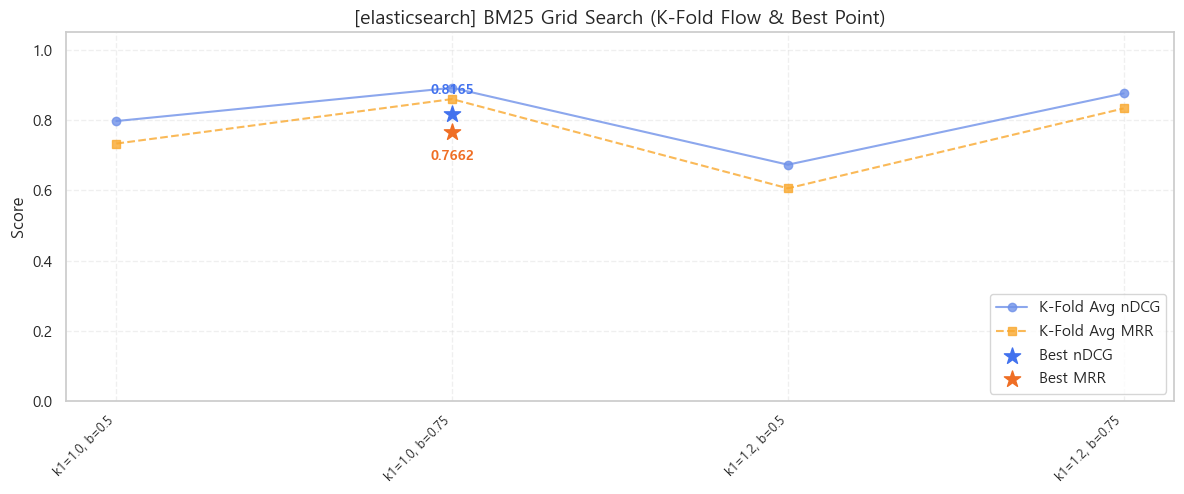

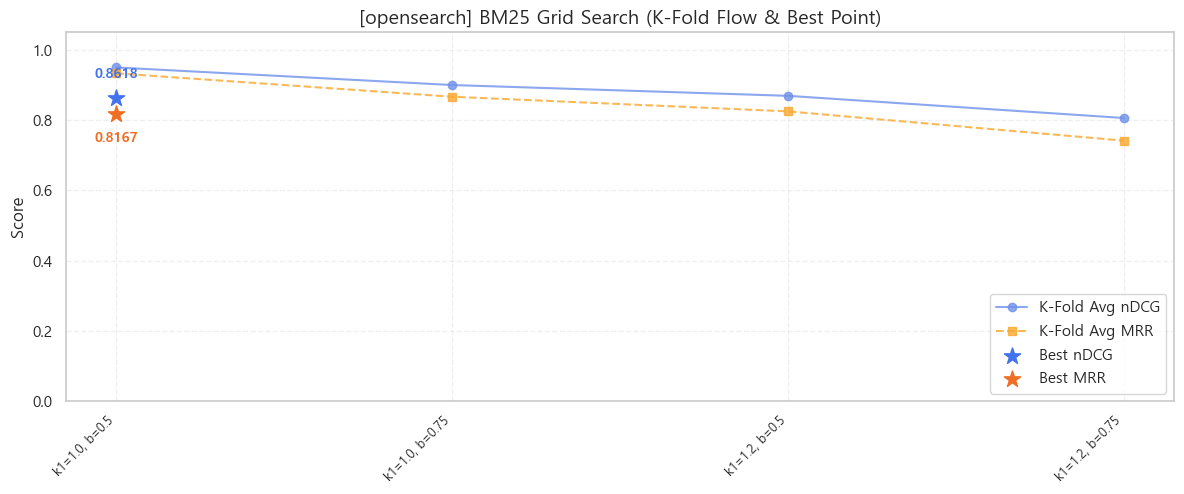

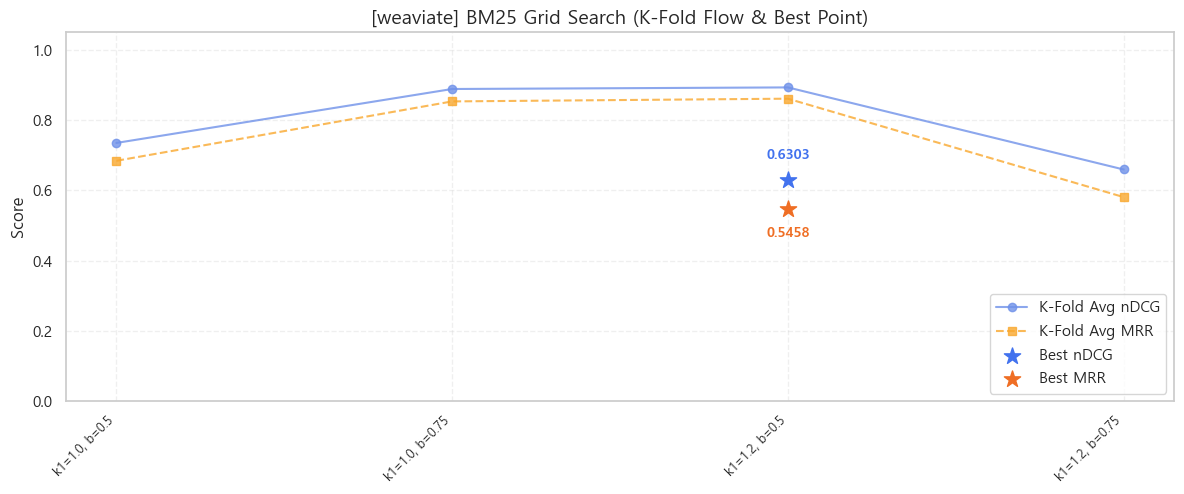

   ▶ [elasticsearch] Heatmap Saved: eval/db_test\bm25\elasticsearch_bm25_heatmap_20251201_1325.png
   ▶ [opensearch] Heatmap Saved: eval/db_test\bm25\opensearch_bm25_heatmap_20251201_1325.png
   ▶ [weaviate] Heatmap Saved: eval/db_test\bm25\weaviate_bm25_heatmap_20251201_1325.png


In [ ]:
# BM25 Grid Search
BM_RETRIEVER_K   = 30
BM_SAMPLE_SIZE   = 1000

BM25_QTYPE = config["retriever"]["bm25"].get("qtype", "multi_match")

K1_LIST = [1.0, 1.2, 1.6, 1.8]
B_LIST  = [0.5, 0.75, 1.0]

M_FIXED, EFC_FIXED, EFS_FIXED = 16, 128, 128

BM_PARAM_GRID = [
    {"k1": k1, "b": b, "m": M_FIXED, "ef_construction": EFC_FIXED, "ef_search": EFS_FIXED}
    for k1, b in product(K1_LIST, B_LIST)
]

# =========================
# 1. BM25용 Retriever 팩토리
# =========================
def get_bm25_retriever(db: str, index_name: str, params: dict):
    if db == "opensearch":
        return OpenSearchTextRetriever(
            os_client=os_client,
            index_name=index_name,
            qtype=BM25_QTYPE,
            k=BM_RETRIEVER_K,
            use_morph=True,
            use_question_field=True,
        )
    elif db == "elasticsearch":
        return ElasticsearchTextRetriever(
            es_client=es_client,
            index_name=index_name,
            k=BM_RETRIEVER_K,
            use_morph=True,
            use_question_field=True,
        )
    elif db == "weaviate":
        return WeaviateHybridRetriever(
            client=wv_client,
            index_name=index_name,
            k=BM_RETRIEVER_K,
            k1=params["k1"],
            b=params["b"],
            alpha=0,
            use_morph=True,
            use_question_field=True,
        )
    else:
        raise ValueError(f"Unknown DB: {db}")


# =========================
# 2. BM25 Evaluate Worker
# =========================
async def evaluate_bm_worker(db: str, index_name: str, params: dict, split: str):
    """BM25 그리드서치용 평가 함수"""
    async with SEMAPHORE:
        try:
            sampled = VAL_QUERIES_BY_DB.get(db) if split == "dev" else TEST_QUERIES_BY_DB.get(db)

            if not sampled:
                return None

            if len(sampled) > BM_SAMPLE_SIZE:
                sampled = random.sample(sampled, BM_SAMPLE_SIZE)

            retriever = get_bm25_retriever(db, index_name, params)

            tasks = [retriever.ainvoke(q) for q, _ in sampled]
            results = await asyncio.gather(*tasks, return_exceptions=False)

            ndcg_scores, mrr_scores = [], []
            for (q, gt), docs in zip(sampled, results):
                retrieved_ids = [
                    str(
                        d.metadata.get("_id")
                        or d.metadata.get("uuid")
                        or d.metadata.get("id")
                        or (d.get("_id") if isinstance(d, dict) else None)
                        or (d.get("uuid") if isinstance(d, dict) else None)
                    )
                    for d in docs
                ]
                retrieved_ids = [rid for rid in retrieved_ids if rid and rid != "None"]

                ndcg_scores.append(compute_ndcg_at_k(docs, gt, BM_RETRIEVER_K))
                mrr_scores.append(compute_mrr_at_k(retrieved_ids, gt, BM_RETRIEVER_K))

            avg_ndcg = sum(ndcg_scores) / len(ndcg_scores) if ndcg_scores else 0.0
            avg_mrr  = sum(mrr_scores) / len(mrr_scores) if mrr_scores else 0.0

            return {
                "db": db,
                "index": index_name,
                "k1": params["k1"],
                "b":  params["b"],
                "split": split,
                f"nDCG@{BM_RETRIEVER_K}": avg_ndcg,
                f"MRR@{BM_RETRIEVER_K}":  avg_mrr,
            }
        except Exception as e:
            print(f"🚨 [Eval Fail] {index_name} ({split}): {e}")
            return None


# =========================
# 3. BM25 Grid Search 메인
# =========================
async def run_bm25_grid_search():
    print(f"🚀 [Start] BM25 Grid Search (조합: {len(BM_PARAM_GRID)}개 x {len(DB_CONFIGS)} DB)")

    # 0) 먼저 전체 데이터 벡터화 (없으면 생성)
    await prepare_vectors_once()

    # 1) 인덱스 생성 + 업로드 (공통 setup_index_worker 사용)
    setup_tasks   = [setup_index_worker(db, p) for db in DB_CONFIGS.keys() for p in BM_PARAM_GRID]
    setup_results = await asyncio.gather(*setup_tasks)

    valid_indices: list[tuple[str, str, dict]] = []
    for res in setup_results:
        if res is None:
            continue
        db, idx_name, params = res
        valid_indices.append((db, idx_name, params))

    if not valid_indices:
        print("🚨 유효한 인덱스가 없습니다. (setup 실패)")
        return

    # 2) Dev 평가
    print(f"⚖️  K-fold 평가(dev) 시작 ...")

    dev_tasks = [
        evaluate_bm_worker(db, idx, p, split="dev")
        for db, idx, p in valid_indices
    ]
    dev_results = await asyncio.gather(*dev_tasks)
    dev_results = [r for r in dev_results if r is not None]

    df = pd.DataFrame(dev_results)
    if df.empty:
        print("🚨 평가 결과가 없습니다.")
        return

    # Test 결과/베스트 플래그 컬럼 추가
    test_ndcg_col = f"Best_nDCG@{BM_RETRIEVER_K}"
    test_mrr_col  = f"Best_MRR@{BM_RETRIEVER_K}"
    df[test_ndcg_col] = float("nan")
    df[test_mrr_col]  = float("nan")
    df["is_best"]     = False

    # 3) DB별로 Dev 기준 Best (k1,b) 골라서 Test 1회
    print("\n🏁 [Best Param 평가]")
    for db in df["db"].unique():
        sub = df[df["db"] == db]
        if sub.empty:
            continue

        best_idx = sub[f"nDCG@{BM_RETRIEVER_K}"].idxmax()
        best_row = df.loc[best_idx]
        best_k1  = best_row["k1"]
        best_b   = best_row["b"]
        best_index_name = best_row["index"]

        print(f"   ▶ [{db}] Best Param from Dev: k1={best_k1}, b={best_b}")

        test_sample = TEST_QUERIES_BY_DB.get(db) or []
        if not test_sample:
            print(f"      ⚠️ [{db}] test 데이터 없음. Test 평가 생략.")
            continue

        test_res = await evaluate_bm_worker(
            db,
            best_index_name,
            {"k1": best_k1, "b": best_b, "m": M_FIXED, "ef_construction": EFC_FIXED, "ef_search": EFS_FIXED},
            split="test",
        )
        if not test_res:
            print(f"      ⚠️ [{db}] test 평가 실패.")
            continue

        df.loc[best_idx, test_ndcg_col] = test_res[f"nDCG@{BM_RETRIEVER_K}"]
        df.loc[best_idx, test_mrr_col]  = test_res[f"MRR@{BM_RETRIEVER_K}"]
        df.loc[best_idx, "is_best"]     = True

    # 4) 저장 + 그래프
    df = df.sort_values(by=["db", f"nDCG@{BM_RETRIEVER_K}"], ascending=[True, False])

    timestamp_str    = datetime.now().strftime('%Y%m%d_%H%M')
    BM25_FOLDER_PATH = os.path.join(BASE_PATH, "db_test", "bm25")
    BM25_CSV_PATH    = os.path.join(BM25_FOLDER_PATH, f"bm25_{timestamp_str}.csv")
    ensure_dir(BM25_CSV_PATH)
    df.to_csv(BM25_CSV_PATH, index=False, encoding="utf-8-sig")

    # ---------- Visualization ----------
    # Line plot 생성 루프
    for db in df["db"].unique():
        sub = df[df["db"] == db].copy()
        sub.sort_values(by=["k1", "b"], inplace=True)
        sub.reset_index(drop=True, inplace=True)

        x_labels = [f"k1={row['k1']}, b={row['b']}" for _, row in sub.iterrows()]
        x_pos    = range(len(sub))

        fig, ax = plt.subplots(figsize=(12, 6))

        ax.plot(
            x_pos,
            sub[f"nDCG@{BM_RETRIEVER_K}"],
            marker="o",
            linestyle="-",
            color="#6f91e9",
            label="K-Fold Avg nDCG",
            alpha=0.8,
        )
        ax.plot(
            x_pos,
            sub[f"MRR@{BM_RETRIEVER_K}"],
            marker="s",
            linestyle="--",
            color="#f9a82e",
            label="K-Fold Avg MRR",
            alpha=0.8,
        )

        best_rows = sub[sub["is_best"] == True]
        if not best_rows.empty:
            best_idx  = best_rows.index[0]
            best_ndcg = best_rows.iloc[0].get(f"Best_nDCG@{BM_RETRIEVER_K}")
            best_mrr  = best_rows.iloc[0].get(f"Best_MRR@{BM_RETRIEVER_K}")

            if pd.notna(best_ndcg):
                ax.scatter(best_idx, best_ndcg, color="#4272ee", s=150, zorder=10, label="Best nDCG", marker="*")
                ax.text(
                    best_idx,
                    best_ndcg + 0.05,
                    f"{best_ndcg:.4f}",
                    ha="center",
                    va="bottom",
                    color="#4272ee",
                    fontweight="bold",
                    fontsize=10,
                )

            if pd.notna(best_mrr):
                ax.scatter(best_idx, best_mrr, color="#ef6e24", s=150, zorder=10, label="Best MRR", marker="*")
                ax.text(
                    best_idx,
                    best_mrr - 0.05,
                    f"{best_mrr:.4f}",
                    ha="center",
                    va="top",
                    color="#ef6e24",
                    fontweight="bold",
                    fontsize=10,
                )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
        ax.set_title(f"[{db}] BM25 Grid Search (K-Fold Flow & Best Point)", fontsize=14)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.legend(loc="lower right")
        ax.grid(True, linestyle="--", alpha=0.3)
        
        plt.tight_layout(rect=[0, 0.15, 1, 1])
        BM_IMG_PATH = os.path.join(BM25_FOLDER_PATH, f"{db}_bm25_k1_b_{timestamp_str}.png")
        ensure_dir(BM_IMG_PATH)
        plt.savefig(BM_IMG_PATH)

        plt.show()

    # heatmap 생성 루프
    for db_name in df["db"].unique():
        subset = df[df['db'] == db_name].copy()
        if subset.empty:
            continue

        # 피벗 테이블 생성 (행: k1, 열: b)
        pivot_ndcg = subset.pivot(index='k1', columns='b', values=f"nDCG@{BM_RETRIEVER_K}")
        pivot_mrr  = subset.pivot(index='k1', columns='b', values=f"MRR@{BM_RETRIEVER_K}")
        
        # 인덱스 정렬 (k1이 y축, b가 x축이 됨)
        pivot_ndcg.sort_index(ascending=True, inplace=True)
        pivot_mrr.sort_index(ascending=True, inplace=True)

        # 캔버스 설정 (1행 2열)
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f'{db_name.upper()} - BM25 Parameter Tuning (k1 vs b)', fontsize=16, fontweight='bold')

        # Heatmap 1: nDCG
        sns.heatmap(pivot_ndcg, ax=axes[0], annot=True, fmt=".4f", cmap="YlGnBu", 
                    linewidths=.5, cbar_kws={'label': 'Score'})
        axes[0].set_title(f'nDCG@{BM_RETRIEVER_K} Heatmap ({db_name})', fontsize=14)
        axes[0].set_xlabel('b (Length Normalization)', fontsize=12)
        axes[0].set_ylabel('k1 (Term Saturation)', fontsize=12)

        # Heatmap 2: MRR
        sns.heatmap(pivot_mrr, ax=axes[1], annot=True, fmt=".4f", cmap="YlOrRd", 
                    linewidths=.5, cbar_kws={'label': 'Score'})
        axes[1].set_title(f'MRR@{BM_RETRIEVER_K} Heatmap ({db_name})', fontsize=14)
        axes[1].set_xlabel('b (Length Normalization)', fontsize=12)
        axes[1].set_ylabel('k1 (Term Saturation)', fontsize=12)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 타이틀 공간 확보
        
        # 히트맵 저장
        heatmap_save_name = f"{db_name}_bm25_heatmap_{timestamp_str}.png"
        heatmap_path = os.path.join(BM25_FOLDER_PATH, heatmap_save_name)
        plt.savefig(heatmap_path, dpi=300)
        print(f"   ▶ [{db_name}] Heatmap Saved: {heatmap_path}")
        plt.close(fig)

# 실행
await run_bm25_grid_search()

In [7]:
# BM25 인덱스 정리
for p in BM_PARAM_GRID:
    for db, config in DB_CONFIGS.items():
        idx_name = make_index_name(config["base_name"], db, p)
        
        try:
            if db == "opensearch":
                os_client.indices.delete(index=idx_name, ignore=[400, 404])
            elif db == "elasticsearch":
                es_client.indices.delete(index=idx_name, ignore=[400, 404])
            elif db == "weaviate":
                wv_client.collections.delete(idx_name)
                
            print(f"Deleted: [{db}] {idx_name}")
            
        except Exception as e:
            pass

print("✨ 모든 BM 인덱스 삭제 완료.")

Deleted: [opensearch] kgs_index_opensearch_k1_1_0_b_0_5_m_16_efs_128_efc_128


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\3597156355.py:10: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=idx_name, ignore=[400, 404])


Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_0_b_0_5_m_16_efs_128_efc_128
Deleted: [weaviate] Kgs_weaviate_k1_1_0_b_0_5_m_16_efs_128_efc_128
Deleted: [opensearch] kgs_index_opensearch_k1_1_0_b_0_75_m_16_efs_128_efc_128
Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_0_b_0_75_m_16_efs_128_efc_128
Deleted: [weaviate] Kgs_weaviate_k1_1_0_b_0_75_m_16_efs_128_efc_128
Deleted: [opensearch] kgs_index_opensearch_k1_1_2_b_0_5_m_16_efs_128_efc_128
Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_2_b_0_5_m_16_efs_128_efc_128
Deleted: [weaviate] Kgs_weaviate_k1_1_2_b_0_5_m_16_efs_128_efc_128
Deleted: [opensearch] kgs_index_opensearch_k1_1_2_b_0_75_m_16_efs_128_efc_128
Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_2_b_0_75_m_16_efs_128_efc_128
Deleted: [weaviate] Kgs_weaviate_k1_1_2_b_0_75_m_16_efs_128_efc_128
✨ 모든 BM 인덱스 삭제 완료.


In [ ]:
# VectorSearch(HNSW) Grid Search
# https://aws.amazon.com/ko/blogs/tech/choose-the-k-nn-algorithm-for-your-billion-scale-use-case-with-opensearch/
VS_RETRIEVER_K  = 30
VS_SAMPLE_SIZE  = 1000

M_LIST   = [8, 16, 32, 64]
EFC_LIST = [32, 128, 256, 512]
EFS_LIST = [32, 128, 256, 512]

K1_FIXED, B_FIXED = 1.2, 0.75

VS_PARAM_GRID = [
    {"k1": K1_FIXED, "b": B_FIXED, "m": m, "ef_construction": efc, "ef_search": efs}
    for m, efc, efs in product(M_LIST, EFC_LIST, EFS_LIST)
]

# =========================
# 1. VectorSearch용 Retriever 팩토리
# =========================
def build_vector_retriever(db: str, index_name: str, params: dict, k: int):
    """ Vector Search용 Retriever 생성 """
    efs = params["ef_search"]

    if db == "opensearch":
        vector_store = get_opensearch_vectorstore(index_name=index_name)
        return vector_store.as_retriever(
            search_type="similarity",
            search_kwargs={"k": k},
        )

    elif db == "elasticsearch":
        vector_store = get_es_vectorstore(index_name=index_name)
        return vector_store.as_retriever(
            search_kwargs={
                "k": k,
                "num_candidates": max(k + 1, efs),  # per-query 튜닝
            }
        )

    elif db == "weaviate":
        # alpha=1.0 → 순수 벡터 / alpha 조정하면 hybrid
        return WeaviateHybridRetriever(
            client=wv_client,
            index_name=index_name,
            text_key="text",
            k=k,
            alpha=1.0,
            k1=params["k1"],
            b=params["b"],
            use_morph=True,
            use_question_field=True,
        )


# =========================
# 2. VectorSearch 평가 워커 (Dev / Test 공용)
# =========================
async def evaluate_hnsw_worker(db: str, index_name: str, params: dict, split: str):
    async with SEMAPHORE:
        # 1. 데이터셋 선택 및 샘플링
        sampled = VAL_QUERIES_BY_DB.get(db) if split == "dev" else TEST_QUERIES_BY_DB.get(db)

        if not sampled:
            return None

        if len(sampled) > VS_SAMPLE_SIZE:
            sampled = random.sample(sampled, VS_SAMPLE_SIZE)

        # 2. Retriever 생성
        retriever = build_vector_retriever(db, index_name, params, VS_RETRIEVER_K)
        if not retriever:
            return None

        ndcg_scores, mrr_scores = [], []
        latencies_ms = []   # 쿼리 속도 기록용

        # 3. 쿼리 수행
        for q, gt in sampled:
            docs = []
            start = time.perf_counter()
            try:
                docs = await asyncio.wait_for(retriever.ainvoke(q), timeout=PER_QUERY_TIMEOUT)
            except Exception:
                docs = []
            end = time.perf_counter()

            latencies_ms.append((end - start) * 1000.0)  # ms

            retrieved_ids = [
                str(d.metadata.get("_id") or d.metadata.get("uuid") or d.metadata.get("id"))
                for d in docs
            ]
            retrieved_ids = [rid for rid in retrieved_ids if rid and rid != "None"]

            ndcg_scores.append(compute_ndcg_at_k(docs, gt, VS_RETRIEVER_K))
            mrr_scores.append(compute_mrr_at_k(retrieved_ids, gt, VS_RETRIEVER_K))

        cnt = len(ndcg_scores)
        avg_ndcg = sum(ndcg_scores) / cnt if cnt else 0.0
        avg_mrr  = sum(mrr_scores) / cnt if cnt else 0.0
        avg_latency_ms = sum(latencies_ms) / len(latencies_ms) if latencies_ms else 0.0

        return {
            "db": db,
            "index": index_name,
            "m": params["m"],
            "efc": params["ef_construction"],
            "efs": params["ef_search"],
            "split": split,
            f"nDCG@{VS_RETRIEVER_K}": avg_ndcg,
            f"MRR@{VS_RETRIEVER_K}": avg_mrr,
            "latency_ms": avg_latency_ms,
        }


# =========================
# 3. HNSW Grid Search 메인
# =========================
async def run_hnsw_grid_search():
    print(f"🚀 [Start] HNSW Grid Search (조합: {len(VS_PARAM_GRID)}개 x {len(DB_CONFIGS)} DB)")

    timestamp_str = datetime.now().strftime('%Y%m%d_%H%M')
    VS_FOLDER_PATH = os.path.join(BASE_PATH, "db_test", "Vectorsearch")
    VS_CSV_PATH    = os.path.join(VS_FOLDER_PATH, f'vs_{timestamp_str}.csv')
    ensure_dir(VS_CSV_PATH)

    # 1. 벡터 생성 (한 번만 수행)
    await prepare_vectors_once()

    # 2. 인덱스 생성 + 업로드 + Dev 평가 워커 준비
    setup_tasks = [
        asyncio.create_task(setup_index_worker(db, p))
        for p in VS_PARAM_GRID
        for db in DB_CONFIGS.keys()
    ]
    total = len(setup_tasks)
    print(f"⚡ 인덱스 빌드/업로드 + Dev 평가 시작 ({total}개 작업)...")

    dev_results = []
    done = 0

    # 3. 비동기 작업 완료되는 순서대로 처리 및 즉시 저장
    for fut in asyncio.as_completed(setup_tasks):
        try:
            res = await fut
            if res is None:
                done += 1
                print(f"[{done}/{total}] ❌ setup 실패")
                continue

            db, idx_name, params = res
        except Exception as e:
            done += 1
            print(f"[{done}/{total}] ❌ setup 예외: {e}")
            continue

        # 바로 Dev 평가 수행
        dev_res = await evaluate_hnsw_worker(db, idx_name, params, split="dev")
        done += 1

        if dev_res:
            print(
                f"[{done}/{total}] ✅ Dev 완료: db={db}, "
                f"m={params['m']}, efc={params['ef_construction']}, efs={params['ef_search']} "
                f"-> nDCG: {dev_res.get(f'nDCG@{VS_RETRIEVER_K}'):.4f}"
            )

            dev_results.append(dev_res)

            # 결과 바로 append 저장
            df_chunk    = pd.DataFrame([dev_res])
            file_exists = os.path.isfile(VS_CSV_PATH)

            try:
                df_chunk.to_csv(
                    VS_CSV_PATH,
                    mode="a",
                    index=False,
                    header=not file_exists,
                    encoding="utf-8-sig",
                )
            except Exception as save_err:
                print(f"⚠️ 저장 실패: {save_err}")
        else:
            print(f"[{done}/{total}] ⚠️ Dev 평가 결과 없음: db={db}")

    # 4. 전체 Dev 평가 완료 후 데이터 정리
    if not dev_results:
        print("🚨 평가 결과가 없습니다.")
        return

    df = pd.DataFrame(dev_results)

    test_ndcg_col = f"Best_nDCG@{VS_RETRIEVER_K}"
    test_mrr_col  = f"Best_MRR@{VS_RETRIEVER_K}"
    df[test_ndcg_col] = float("nan")
    df[test_mrr_col]  = float("nan")
    df["is_best"]     = False

    # 5. Best 선정 및 Test 평가
    print("\n🏁 [Best Param 평가]")
    for db in df["db"].unique():
        sub = df[df["db"] == db]
        if sub.empty:
            continue

        best_idx = sub[f"nDCG@{VS_RETRIEVER_K}"].idxmax()
        best_row = df.loc[best_idx]

        best_params = {
            "m": best_row["m"],
            "ef_construction": best_row["efc"],
            "ef_search": best_row["efs"],
            "k1": K1_FIXED,
            "b":  B_FIXED,
        }
        best_index_name = best_row["index"]

        print(
            f"   ▶ [{db}] Best: m={best_params['m']}, "
            f"efc={best_params['ef_construction']}, efs={best_params['ef_search']}"
        )

        test_res = await evaluate_hnsw_worker(db, best_index_name, best_params, split="test")

        if test_res:
            df.loc[best_idx, test_ndcg_col] = test_res[f"nDCG@{VS_RETRIEVER_K}"]
            df.loc[best_idx, test_mrr_col]  = test_res[f"MRR@{VS_RETRIEVER_K}"]
            df.loc[best_idx, "is_best"]     = True
        else:
            print(f"      ⚠️ [{db}] Test 평가 실패")

    # 6. 최종 정렬 및 전체 덮어쓰기 저장
    df = df.sort_values(by=["db", f"nDCG@{VS_RETRIEVER_K}"], ascending=[True, False])

    print("\n⏱ DB별 평균 latency 요약 (ms)")
    print(df.groupby("db")["latency_ms"].describe().round(2).to_string())

    df.to_csv(VS_CSV_PATH, index=False, encoding="utf-8-sig")

    try:
        print("\n📊 [Top Results]")
        print(
            df.groupby("db")
            .head(1)[
                [   "db",
                    "m",
                    "efc",
                    "efs",
                    f"nDCG@{VS_RETRIEVER_K}",
                    test_ndcg_col,
                ]
            ]
            .to_string(index=False)
        )
    except:
        pass

    # 7. 시각화
    for db in df["db"].unique():
        sub = df[df["db"] == db].copy()

        # 상위 10개의 점수만 그래프로 만들기
        sub = sub.sort_values(by=f"nDCG@{VS_RETRIEVER_K}", ascending=False).head(10)
        sub.reset_index(drop=True, inplace=True)

        x_labels = [f"m={row['m']}\nefc={row['efc']}\nefs={row['efs']}" for _, row in sub.iterrows()]
        x_pos    = range(len(sub))

        fig, ax = plt.subplots(figsize=(12, 6))

        ndcg_col = f"nDCG@{VS_RETRIEVER_K}"
        mrr_col  = f"MRR@{VS_RETRIEVER_K}"

        # BM25와 맞춘 컬러 팔레트
        ndcg_color       = "#6f91e9"  # 라인 nDCG
        mrr_color        = "#f9a82e"  # 라인 MRR
        best_ndcg_color  = "#4272ee"  # 별표 nDCG
        best_mrr_color   = "#ef6e24"  # 별표 MRR
        latency_color    = "#999999"  # latency는 중립 회색

        # 점수 라인 (왼쪽 y축)
        l1 = ax.plot(
            x_pos,
            sub[ndcg_col],
            marker="o",
            linestyle="-",
            color=ndcg_color,
            label="Dev Avg nDCG",
            alpha=0.8,
        )
        l2 = ax.plot(
            x_pos,
            sub[mrr_col],
            marker="s",
            linestyle="--",
            color=mrr_color,
            label="Dev Avg MRR",
            alpha=0.8,
        )

        # Best 표시 (Test 점수)
        best_rows = sub[sub["is_best"] == True]
        s1 = s2 = None
        if not best_rows.empty:
            b_idx  = best_rows.index[0]
            b_ndcg = best_rows.iloc[0].get(test_ndcg_col)
            b_mrr  = best_rows.iloc[0].get(test_mrr_col)

            if pd.notna(b_ndcg):
                s1 = ax.scatter(
                    b_idx,
                    b_ndcg,
                    s=200,
                    marker="*",
                    zorder=10,
                    color=best_ndcg_color,
                    label="Best nDCG",
                )
                ax.annotate(
                    f"{b_ndcg:.4f}",
                    xy=(b_idx, b_ndcg),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                    color=best_ndcg_color,
                )

            if pd.notna(b_mrr):
                s2 = ax.scatter(
                    b_idx,
                    b_mrr,
                    s=200,
                    marker="*",
                    zorder=10,
                    color=best_mrr_color,
                    label="Best MRR",
                )
                ax.annotate(
                    f"{b_mrr:.4f}",
                    xy=(b_idx, b_mrr),
                    xytext=(0, -15),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=10,
                    fontweight="bold",
                    color=best_mrr_color,
                )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("HNSW Params (m / efc / efs)")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"[{db}] HNSW Grid Search (Score + Latency)", fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.3)

        # Latency 축 (오른쪽 y축) - 회색 라인으로 살짝만
        ax2 = ax.twinx()
        latency_s = sub["latency_ms"] / 1000.0  # ms -> s
        l3 = ax2.plot(
            x_pos,
            latency_s,
            marker="x",
            linestyle=":",
            color=latency_color,
            label="Avg Latency (s)",
            alpha=0.8,
        )
        ax2.set_ylabel("Latency (seconds)")

        # legend 합치기 (BM25처럼 한 군데 모아서)
        handles = l1 + l2 + l3
        if s1 is not None:
            handles.append(s1)
        if s2 is not None:
            handles.append(s2)
        labels = [h.get_label() for h in handles]
        ax.legend(handles, labels, loc="lower right")

        VS_IMG_PATH = os.path.join(VS_FOLDER_PATH, f"{db}_vs_m_efc_efs_{timestamp_str}.png")
        plt.tight_layout(rect=[0, 0.15, 1, 1])
        plt.savefig(VS_IMG_PATH)
        plt.show()

# 실행
await run_hnsw_grid_search()


In [9]:
# HNSW 인덱스 정리
for p in VS_PARAM_GRID:
    for db, vs_config in DB_CONFIGS.items():
        idx_name = make_index_name(vs_config["base_name"], db, p)
        
        try:
            if db == "opensearch":
                os_client.indices.delete(index=idx_name, ignore=[400, 404])
            elif db == "elasticsearch":
                es_client.indices.delete(index=idx_name, ignore=[400, 404])
            elif db == "weaviate":
                wv_client.collections.delete(idx_name)
                
            print(f"Deleted: [{db}] {idx_name}")
            
        except Exception as e:
            pass

print("✨ 모든 VS 인덱스 삭제 완료.")

Deleted: [opensearch] kgs_index_opensearch_k1_1_2_b_0_75_m_8_efs_32_efc_32


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\447093696.py:10: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=idx_name, ignore=[400, 404])


Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_2_b_0_75_m_8_efs_32_efc_32
Deleted: [weaviate] Kgs_weaviate_k1_1_2_b_0_75_m_8_efs_32_efc_32
Deleted: [opensearch] kgs_index_opensearch_k1_1_2_b_0_75_m_16_efs_32_efc_32
Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_2_b_0_75_m_16_efs_32_efc_32
Deleted: [weaviate] Kgs_weaviate_k1_1_2_b_0_75_m_16_efs_32_efc_32
Deleted: [opensearch] kgs_index_opensearch_k1_1_2_b_0_75_m_32_efs_32_efc_32
Deleted: [elasticsearch] kgs_index_elasticsearch_k1_1_2_b_0_75_m_32_efs_32_efc_32
Deleted: [weaviate] Kgs_weaviate_k1_1_2_b_0_75_m_32_efs_32_efc_32
✨ 모든 VS 인덱스 삭제 완료.


### Question, Tokenizer 사용여부

In [13]:
#  (BM25) Question / Tokenizer
timestamp_str   = datetime.now().strftime('%Y%m%d_%H%M%S')
QT_FOLDER_PATH  = os.path.join(BASE_PATH, "db_test", "bm25_question_token")
QT_CSV_PATH     = os.path.join(QT_FOLDER_PATH, f'qt_{timestamp_str}.csv')

BM25_CONCURRENCY = 100
bm25_sem         = asyncio.Semaphore(BM25_CONCURRENCY)

with open('config/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

bm25_config  = config["retriever"].get("bm25", {})
QT_TEST_SIZE = 500

# ---------------------------------------------------------
# 1. 리트리버 생성 헬퍼 + 공통 설정
# ---------------------------------------------------------
def create_retriever_for_condition(
    retriever_class,
    use_morph: bool,
    use_question: bool,
    **kwargs,
):
    """조건 플래그 기반 리트리버 생성기"""
    params = kwargs.copy()
    params["use_morph"]         = use_morph
    params["use_question_field"] = use_question
    return retriever_class(**params)

os_base_params = {
    "os_client": os_client,
    "index_name": OS_TEST_INDEX,
    "k": RETRIEVER_K,
    "qtype": bm25_config.get("qtype", "multi_match"),
}

es_base_params = {
    "es_client": es_client,
    "index_name": ES_TEST_INDEX,
    "k": RETRIEVER_K,
}

wv_base_params = {
    "client": wv_client,
    "index_name": WV_TEST_COLLECTION,
    "k": RETRIEVER_K,
    "alpha": BM_ALPHA,
}

# (db, retriever_class, base_params)
DB_RETRIEVER_BASE = {
    "opensearch": (OpenSearchTextRetriever, os_base_params),
    "elasticsearch": (ElasticsearchTextRetriever, es_base_params),
    "weaviate": (WeaviateHybridRetriever, wv_base_params),
}

# (model_label, use_morph) 두 가지 버전
MODEL_VARIANTS = [
    ("bm25-nm", False),  # No morph
    ("bm25-m",  True),   # Morph 사용
]

# field_mode: TextOnly / Text+Question
FIELD_MODES = [
    ("TextOnly",      False),
    ("Text+Question", True),
]

# ---------------------------------------------------------
# 2. 리트리버 config 전개
#    → (db_name, model_name, field_mode, retriever)
# ---------------------------------------------------------
retriever_configs = []

for db_name, (retriever_cls, base_params) in DB_RETRIEVER_BASE.items():
    for model_name, use_morph in MODEL_VARIANTS:
        for field_mode, use_question in FIELD_MODES:
            retriever = create_retriever_for_condition(
                retriever_cls,
                use_morph=use_morph,
                use_question=use_question,
                **base_params,
            )
            retriever_configs.append((db_name, model_name, field_mode, retriever))

# ---------------------------------------------------------
# 3. 평가용 쿼리 샘플링
# ---------------------------------------------------------
sampled_queries_para = {
    db: (VAL_QUERIES_BY_DB.get(db, [])[:QT_TEST_SIZE])
    for db in ["opensearch", "elasticsearch", "weaviate"]
}

# ---------------------------------------------------------
# 4. 평가 실행
# ---------------------------------------------------------
async def eval_one_query(
    db: str,
    model_name: str,
    field_mode: str,
    retriever,
    gt_ids_set,
    query_text: str,
):
    docs = await retriever.ainvoke(query_text)

    retrieved_ids = [d.metadata.get("_id") or d.metadata.get("uuid") for d in docs]
    k_val = len(retrieved_ids)

    ndcg = compute_ndcg_at_k(docs, gt_ids_set, k_val)
    mrr  = compute_mrr_at_k(retrieved_ids, gt_ids_set, k_val)
    is_hit = any(doc_id in gt_ids_set for doc_id in retrieved_ids)

    result = {
        "db": db,
        "model": model_name,
        "field_mode": field_mode,
        "query_type": "paraphrase",
        "RETRIEVER_K": k_val,
        "retrieved_count": len(retrieved_ids),
        "gt_count": len(gt_ids_set),
        "nDCG@k": ndcg,
        "MRR@k": mrr,
        "Hit@k": 1.0 if is_hit else 0.0,
    }

    for k_check in [5, 10, 20, 30]:
        sub_ids = retrieved_ids[:k_check]
        cnt = sum(1 for x in sub_ids if x in gt_ids_set)
        result[f"Count@{k_check}"] = cnt

    return result


async def protected_eval_one_query(
    db: str,
    model_name: str,
    field_mode: str,
    retriever,
    gt_ids_set,
    query_text: str,
):
    async with bm25_sem:
        return await eval_one_query(db, model_name, field_mode, retriever, gt_ids_set, query_text)


async def run_bm25_evaluation():
    all_tasks = []

    for (db_name, model_name, field_mode, retriever) in retriever_configs:
        queries = sampled_queries_para.get(db_name, [])
        if not queries:
            continue

        for query_text, gt_ids in queries:
            all_tasks.append(
                protected_eval_one_query(db_name, model_name, field_mode, retriever, gt_ids, query_text)
            )

    print(f"⚡ BM25 총 {len(all_tasks)}개 태스크 평가 시작 ")
    results = await tqdm_asyncio.gather(*all_tasks)
    return [r for r in results if r is not None]


all_results_data = await run_bm25_evaluation()

# ---------------------------------------------------------
# 5. 결과 저장 및 시각화
# ---------------------------------------------------------
df_results = pd.DataFrame(all_results_data)

if not df_results.empty:
    group_keys        = ["db", "model", "field_mode", "query_type"]
    metrics_to_average = ["nDCG@k", "MRR@k", "Hit@k", "Count@5", "Count@10", "Count@20", "Count@30"]
    other_info = ["RETRIEVER_K", "retrieved_count", "gt_count"]

    final_cols = group_keys + other_info + metrics_to_average
    df_results = df_results[[c for c in final_cols if c in df_results.columns]]

    os.makedirs(QT_FOLDER_PATH, exist_ok=True)
    df_results.to_csv(QT_CSV_PATH, index=False, encoding="utf-8-sig")

    avg_metrics_df = (
        df_results.groupby(group_keys)[metrics_to_average]
        .mean()
        .sort_values(by=["db", "nDCG@k"], ascending=False)
    )

    print("\n[📊 평균 지표 요약]")
    print(avg_metrics_df.to_markdown(floatfmt=".4f"))

    # ------------------------
    # 시각화 함수
    # ------------------------
    def plot_field_token_effect(df, metric: str = "nDCG@k"):
        df_ = df.copy()

        def get_label(row):
            is_morph = ("-m" in row["model"]) and ("-nm" not in row["model"]) # 모델명에서 Morph 사용 여부
            is_question_mode = "Question" in row["field_mode"]                # Question 필드 사용 여부

            if not is_morph and not is_question_mode:
                return "Text Only"             # NoMorph + TextOnly
            elif not is_morph and is_question_mode:
                return "Question"              # NoMorph + Text+Question
            elif is_morph and not is_question_mode:
                return "Tokenizer"             # Morph + TextOnly
            else:
                return "Question + Tokenizer"  # Morph + Text+Question

        df_["condition"] = df_.apply(get_label, axis=1)

        hue_order = ["Text Only", "Question", "Tokenizer", "Question + Tokenizer",]
        
        df_plot = df_.groupby(["db", "condition"], as_index=False)[metric].mean()

        existing_hue = [h for h in hue_order if h in df_plot["condition"].unique()]
        if not existing_hue:
            return

        plt.figure(figsize=(12, 8))
        sns.set_style("white")

        ax = sns.barplot(
            data=df_plot,
            x="db",
            y=metric,
            hue="condition",
            hue_order=existing_hue,
            palette="Blues_d",
            edgecolor="black",
            linewidth=1.0,
            zorder=3,
        )

        # 값 표시
        for p in ax.patches:
            h = p.get_height()
            if h <= 0.001:
                continue
            ax.annotate(
                f"{h:.3f}",
                (p.get_x() + p.get_width() / 2, h),
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                xytext=(0, 5),
                textcoords="offset points",
            )

        plt.title(
            f"BM25 Tokenizer & Question Field ({metric})",
            fontsize=18,
            fontweight="bold",
            pad=25,
        )
        plt.ylabel(metric, fontsize=14, fontweight="bold", labelpad=15)
        plt.xlabel("")

        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.05),
            ncol=4,
            frameon=True,
            edgecolor="black",
            framealpha=1,
            fontsize=12,
            columnspacing=1.5,
        )

        sns.despine(left=True, bottom=True, right=True, top=True)
        ax.yaxis.grid(True, color="#EEEEEE", zorder=0)
        ax.tick_params(left=False, bottom=False)
        plt.tight_layout()
        QT_IMG_PATH = os.path.join(QT_FOLDER_PATH, f"question_token({metric})_{timestamp_str}.png")
        plt.savefig(QT_IMG_PATH, dpi=300)
        plt.close()

    # 실제 그래프 생성
    for met in ["nDCG@k", "MRR@k", "Count@5"]:
        plot_field_token_effect(df_results, metric=met)
else:
    print("⚠️ 평가 결과 데이터가 없습니다.")


⚡ BM25 총 6000개 태스크 평가 시작 


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\asyncio\selector_events.py:869: ResourceWarning: unclosed transport <_SelectorSocketTransport fd=2088 read=idle write=<idle, bufsize=0>>
  _warn(f"unclosed transport {self!r}", ResourceWarning, source=self)
100%|██████████| 6000/6000 [01:42<00:00, 58.47it/s]



[📊 평균 지표 요약]
|                                                             |   nDCG@k |   MRR@k |   Hit@k |   Count@5 |   Count@10 |   Count@20 |   Count@30 |
|:------------------------------------------------------------|---------:|--------:|--------:|----------:|-----------:|-----------:|-----------:|
| ('weaviate', 'bm25-m', 'Text+Question', 'paraphrase')       |   0.7320 |  0.6603 |  0.9700 |    0.8260 |     0.9060 |     0.9460 |     0.9700 |
| ('weaviate', 'bm25-nm', 'Text+Question', 'paraphrase')      |   0.5870 |  0.5201 |  0.8200 |    0.6220 |     0.7120 |     0.7820 |     0.8200 |
| ('weaviate', 'bm25-m', 'TextOnly', 'paraphrase')            |   0.5038 |  0.4135 |  0.8180 |    0.5800 |     0.6720 |     0.7620 |     0.8180 |
| ('weaviate', 'bm25-nm', 'TextOnly', 'paraphrase')           |   0.3499 |  0.2781 |  0.6080 |    0.3820 |     0.4740 |     0.5480 |     0.6080 |
| ('opensearch', 'bm25-m', 'Text+Question', 'paraphrase')     |   0.8929 |  0.8591 |  1.0000 |    0.9480 |    


🔹 Question 가중치 = 0 평가 시작


100%|██████████| 500/500 [00:17<00:00, 27.98it/s]


  ✅ opensearch / w=0 → nDCG=0.6376, MRR=0.5558, Count@5=0.734


100%|██████████| 500/500 [00:10<00:00, 48.93it/s]


  ✅ elasticsearch / w=0 → nDCG=0.5562, MRR=0.4673, Count@5=0.658


...

100%|██████████| 500/500 [00:10<00:00, 49.43it/s]


  ✅ elasticsearch / w=2.5 → nDCG=0.8397, MRR=0.7919, Count@5=0.922


100%|██████████| 500/500 [00:13<00:00, 36.22it/s]
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\i

  ✅ weaviate / w=2.5 → nDCG=0.5148, MRR=0.4270, Count@5=0.582


c:\Users\user\Desktop\rag\rag_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\Desktop\rag\rag_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\Desktop\rag\rag_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\Desktop\rag\rag_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\Desktop\rag\rag_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  fig.canvas.p

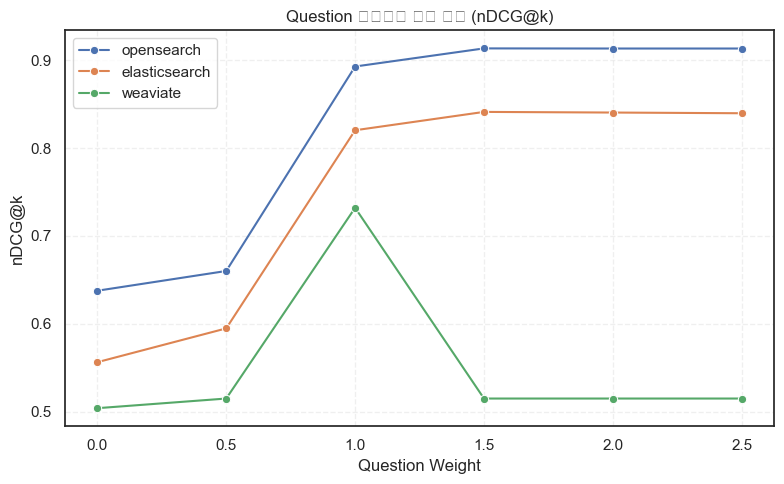

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyp

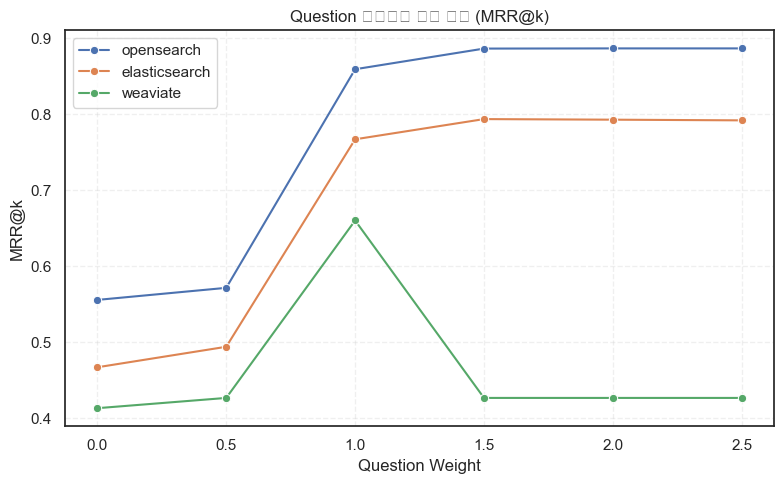

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21980\704733647.py:185: UserWarning: Glyp

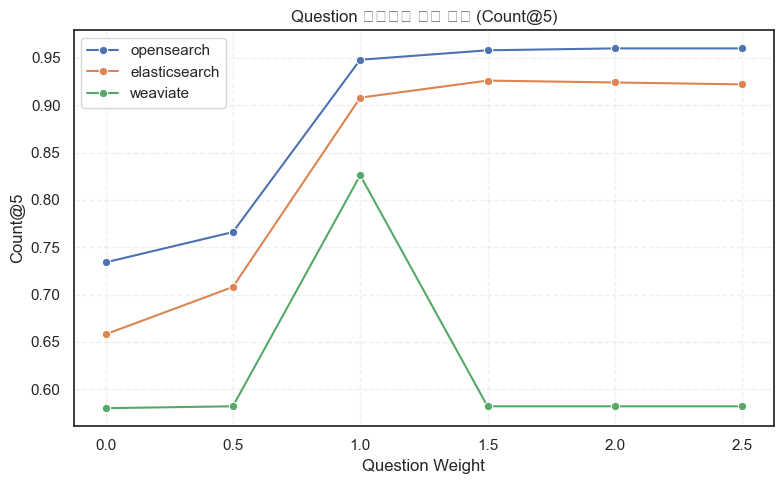

In [14]:
# (BM25) Question Field Weight
QUESTION_WEIGHTS   = [0, 0.5, 1.0, 1.5, 2.0, 2.5]
WEIGHT_TEST_SIZE   = 500

timestamp_str      = datetime.now().strftime('%Y%m%d_%H%M%S')
QW_FOLDER_PATH     = os.path.join(BASE_PATH, "db_test", "bm25_qweight")
QW_CSV_PATH        = os.path.join(QW_FOLDER_PATH, f"qw_{timestamp_str}.csv")
os.makedirs(QW_FOLDER_PATH, exist_ok=True)

bm25_config        = config["retriever"].get("bm25", {})
BM25_QTYPE_LOCAL   = bm25_config.get("qtype", "multi_match")

# ---------------------------------------------------------
# 1. DB별 리트리버 생성
# ---------------------------------------------------------
def create_retriever_for_db(db_name: str, question_weight: float):
    """
    db_name: "opensearch" | "elasticsearch" | "weaviate"
    question_weight: question / question_morph 가중치 (둘 다 동일하게 사용)
    """
    common_kwargs = dict(
        k=RETRIEVER_K,
        use_morph=True,
        use_question_field=True,
        question_boost=question_weight,
        question_morph_boost=question_weight,
    )

    if db_name == "opensearch":
        return OpenSearchTextRetriever(
            os_client=os_client,
            index_name=OS_TEST_INDEX,
            qtype=BM25_QTYPE_LOCAL,
            **common_kwargs,
        )

    elif db_name == "elasticsearch":
        return ElasticsearchTextRetriever(
            es_client=es_client,
            index_name=ES_TEST_INDEX,
            **common_kwargs,
        )

    elif db_name == "weaviate":
        return WeaviateHybridRetriever(
            client=wv_client,
            index_name=WV_TEST_COLLECTION,
            alpha=1e-6,  # BM25 위주로 보고 싶으면 0 근처 / 하이브리드는 적당히 조정
            **common_kwargs,
        )

    else:
        raise ValueError(f"알 수 없는 db_name: {db_name}")


# ---------------------------------------------------------
# 2. 단일 쿼리 평가
# ---------------------------------------------------------
async def _eval_single_query(
    db_name: str,
    retriever,
    query_text: str,
    gt_ids: set[str],
):
    async with bm25_sem:
        try:
            docs = await retriever.ainvoke(query_text)
        except Exception as e:
            print(f"⚠️ [{db_name}] 쿼리 실패: {e} / query={query_text[:30]}...")
            return None

        retrieved_ids = [
            d.metadata.get("_id") or d.metadata.get("uuid")
            for d in docs
        ]
        retrieved_ids = [rid for rid in retrieved_ids if rid]  # None 제거

        k_val = len(retrieved_ids) or 1  # 0 나눗셈 방지

        ndcg = compute_ndcg_at_k(docs, gt_ids, k_val)
        mrr  = compute_mrr_at_k(retrieved_ids, gt_ids, k_val)

        top5 = retrieved_ids[:5]
        cnt5 = sum(1 for x in top5 if x in gt_ids)

        return {
            "nDCG@k": ndcg,
            "MRR@k": mrr,
            "Count@5": cnt5,
        }


# ---------------------------------------------------------
# 3. 리트리버 단위 평가
# ---------------------------------------------------------
async def evaluate_retriever(db_name: str, retriever, queries_with_gt):
    """
    queries_with_gt: [(query_text, gt_ids), ...]
    return: {"nDCG@k": float, "MRR@k": float, "Count@5": float}
    """
    tasks = []
    for query_text, gt_ids in queries_with_gt:
        gt_set = set(gt_ids)
        tasks.append(_eval_single_query(db_name, retriever, query_text, gt_set))

    results = await tqdm_asyncio.gather(*tasks)
    results = [r for r in results if r is not None]

    if not results:
        return {"nDCG@k": 0.0, "MRR@k": 0.0, "Count@5": 0.0}

    df = pd.DataFrame(results)
    return {
        "nDCG@k": df["nDCG@k"].mean(),
        "MRR@k": df["MRR@k"].mean(),
        "Count@5": df["Count@5"].mean(),
    }


# ---------------------------------------------------------
# 4. Question Weight Sweep 실행
# ---------------------------------------------------------
async def run_question_weight_sweep():
    """
    QUESTION_WEIGHTS 리스트에 정의된 question 가중치들을
    각 DB(opensearch, elasticsearch, weaviate)에 대해 평가.
    """
    db_list     = ["opensearch", "elasticsearch", "weaviate"]
    all_results = []

    for w in QUESTION_WEIGHTS:
        print(f"\n🔹 Question 가중치 = {w} 평가 시작")
        for db_name in db_list:
            queries = VAL_QUERIES_BY_DB.get(db_name, [])[:WEIGHT_TEST_SIZE]
            if not queries:
                print(f"  ⚠️ {db_name}: VAL_QUERIES_BY_DB 비어 있음, 스킵")
                continue

            retriever = create_retriever_for_db(db_name, question_weight=w)
            metrics   = await evaluate_retriever(db_name, retriever, queries)

            print(
                f"  ✅ {db_name} / w={w} → "
                f"nDCG={metrics['nDCG@k']:.4f}, "
                f"MRR={metrics['MRR@k']:.4f}, "
                f"Count@5={metrics['Count@5']:.3f}"
            )

            all_results.append(
                {
                    "db": db_name,
                    "weight": w,
                    "nDCG@k": metrics["nDCG@k"],
                    "MRR@k": metrics["MRR@k"],
                    "Count@5": metrics["Count@5"],
                }
            )

    return pd.DataFrame(all_results)


# ---------------------------------------------------------
# 5. 실행 + 저장 + 그래프
# ---------------------------------------------------------
df_results = await run_question_weight_sweep()
df_results.to_csv(QW_CSV_PATH, index=False, encoding="utf-8-sig")

metrics_to_plot = ["nDCG@k", "MRR@k", "Count@5"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=df_results,
        x="weight",
        y=metric,
        hue="db",
        marker="o",
    )
    plt.title(f"Question 가중치별 성능 변화 ({metric})")
    plt.ylabel(metric)
    plt.xlabel("Question Weight")
    plt.xticks(QUESTION_WEIGHTS)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    QW_IMG_PATH = os.path.join(QW_FOLDER_PATH, f"question_weight_{metric}_{timestamp_str}.png")
    plt.savefig(QW_IMG_PATH ,dpi=300)
    plt.show()


### Ensemble Weight 테스트


🔹 Alpha (Vector Weight) = 0.0 평가 중...
   ✅ opensearch | α=0.0 -> nDCG: 0.8927, MRR: 0.8585, Count@5: 0.963
   ✅ elasticsearch | α=0.0 -> nDCG: 0.8182, MRR: 0.7623, Count@5: 0.901
   ✅ weaviate | α=0.0 -> nDCG: 0.7365, MRR: 0.6656, Count@5: 0.830

🔹 Alpha (Vector Weight) = 0.1 평가 중...
   ✅ opensearch | α=0.1 -> nDCG: 0.8899, MRR: 0.8543, Count@5: 0.973
   ✅ elasticsearch | α=0.1 -> nDCG: 0.8318, MRR: 0.7793, Count@5: 0.921
   ✅ weaviate | α=0.1 -> nDCG: 0.7641, MRR: 0.6992, Count@5: 0.868

🔹 Alpha (Vector Weight) = 0.2 평가 중...
   ✅ opensearch | α=0.2 -> nDCG: 0.8875, MRR: 0.8514, Count@5: 0.961
   ✅ elasticsearch | α=0.2 -> nDCG: 0.8422, MRR: 0.7928, Count@5: 0.929
   ✅ weaviate | α=0.2 -> nDCG: 0.7908, MRR: 0.7309, Count@5: 0.897

🔹 Alpha (Vector Weight) = 0.3 평가 중...
   ✅ opensearch | α=0.3 -> nDCG: 0.8793, MRR: 0.8410, Count@5: 0.953
   ✅ elasticsearch | α=0.3 -> nDCG: 0.8464, MRR: 0.7985, Count@5: 0.929
   ✅ weaviate | α=0.3 -> nDCG: 0.8180, MRR: 0.7653, Count@5: 0.907

🔹 Alpha (Ve

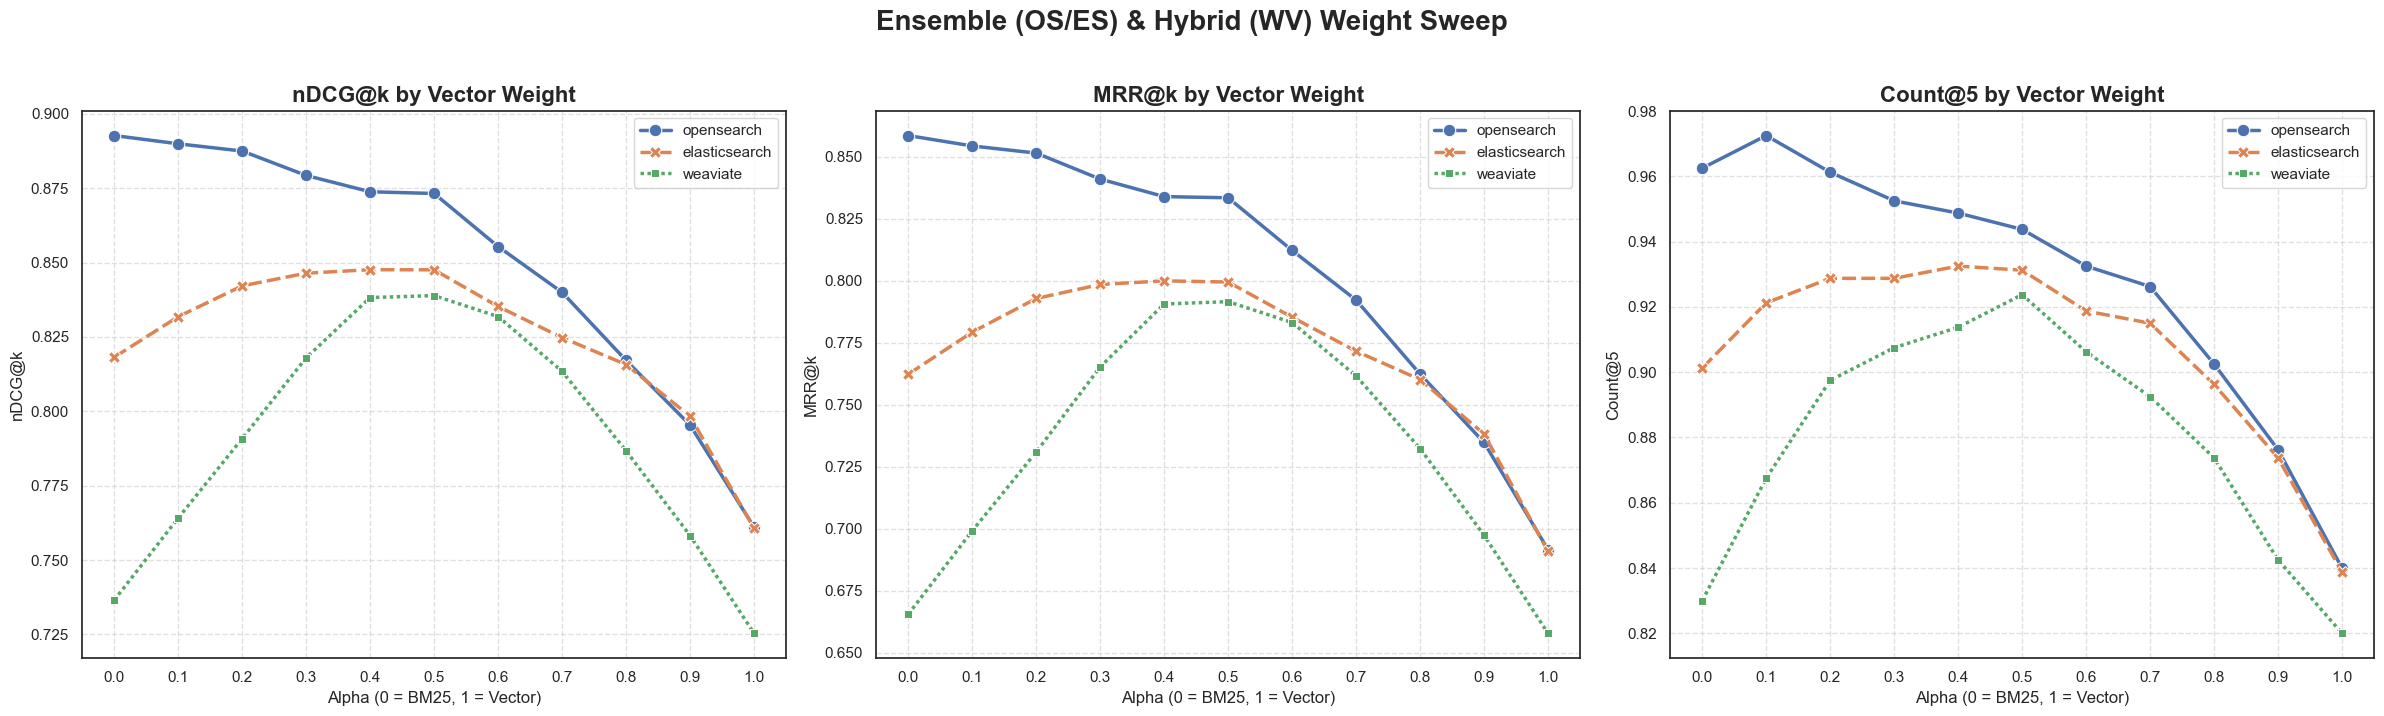

In [ ]:
# Ensemble Retriever Weight(BM25 + Vector)
ENSEMBLE_FOLDER_PATH = os.path.join(BASE_PATH, "db_test", "ensemble")
os.makedirs(ENSEMBLE_FOLDER_PATH, exist_ok=True)

timestamp_str      = datetime.now().strftime("%Y%m%d_%H%M%S")
ENSEMBLE_CSV_PATH  = os.path.join(ENSEMBLE_FOLDER_PATH, f"ensemble_result_{timestamp_str}.csv")

ALPHAS             = np.round(np.arange(0.0, 1.1, 0.1), 1)   # 0.0 ~ 1.0
ENSEMBLE_TEST_SIZE = 1000
BATCH_SIZE         = 3                                       # 쿼리 배치 크기

# ---------------------------------------------------------
# 1. alpha별 Retriever 생성
# ---------------------------------------------------------
def create_retriever_by_alpha(db_name: str, alpha: float):
    """
    db_name: "opensearch" | "elasticsearch" | "weaviate"
    alpha : Vector 비중 (0.0 = TextOnly, 1.0 = VectorOnly)
    """
    # 1) Weaviate: 자체 Hybrid(alpha)로 처리
    if db_name == "weaviate":
        return WeaviateHybridRetriever(
            client=wv_client,
            index_name=WV_TEST_COLLECTION,
            k=RETRIEVER_K,
            alpha=alpha,
            use_morph=True,
            use_question_field=True,
            text_boost=1.0,
            text_morph_boost=1.0,
            question_boost=1.0,
            question_morph_boost=1.0,
            attributes=["text", "question", "text_morph", "question_morph"],
        )

    # 2) OpenSearch / Elasticsearch: BM25 + Vector Ensemble
    bm25_weight   = round(1.0 - alpha, 1)
    vector_weight = round(alpha, 1)

    if db_name == "opensearch":
        bm25 = OpenSearchTextRetriever(
            os_client=os_client,
            index_name=OS_TEST_INDEX,
            k=RETRIEVER_K,
            use_morph=True,
            use_question_field=True,
        )
        vec  = get_opensearch_vectorstore(OS_TEST_INDEX).as_retriever(
            search_kwargs={"k": RETRIEVER_K}
        )

    elif db_name == "elasticsearch":
        bm25 = ElasticsearchTextRetriever(
            es_client=es_client,
            index_name=ES_TEST_INDEX,
            k=RETRIEVER_K,
            use_morph=True,
            use_question_field=True,
        )
        vec  = get_es_vectorstore(ES_TEST_INDEX).as_retriever(
            search_kwargs={"k": RETRIEVER_K, "num_candidates": 256}
        )

    else:
        raise ValueError(f"Unknown DB: {db_name}")

    return EnsembleRetriever(
        retrievers=[bm25, vec],
        weights=[bm25_weight, vector_weight],
    )


# ---------------------------------------------------------
# 2. 단일 쿼리 평가
# ---------------------------------------------------------
async def _eval_single_query_safe(
    db_name: str,
    retriever,
    query_text: str,
    gt_ids: set[str],
):
    try:
        docs = await retriever.ainvoke(query_text)
    except Exception:
        # 필요시 에러 로그 추가 가능
        return None

    retrieved_ids = [
        str(d.metadata.get("_id") or d.metadata.get("uuid") or d.metadata.get("id"))
        for d in docs
    ]
    retrieved_ids = [rid for rid in retrieved_ids if rid and rid != "None"]

    k_val = len(retrieved_ids) or 1

    ndcg = compute_ndcg_at_k(docs, gt_ids, k_val)
    mrr  = compute_mrr_at_k(retrieved_ids, gt_ids, k_val)

    top5 = retrieved_ids[:5]
    cnt5 = sum(1 for x in top5 if x in gt_ids)

    return {
        "nDCG@k": ndcg,
        "MRR@k": mrr,
        "Count@5": cnt5,
    }


# ---------------------------------------------------------
# 3. Retriever 단위 평가 (배치 처리)
# ---------------------------------------------------------
async def evaluate_retriever_safe(db_name: str, retriever, queries_with_gt):
    """
    queries_with_gt: [(query_text, gt_ids), ...]
    """
    results = []
    total   = len(queries_with_gt)

    for start in range(0, total, BATCH_SIZE):
        batch = queries_with_gt[start : start + BATCH_SIZE]

        tasks = []
        for query_text, gt_ids in batch:
            gt_set = {str(g) for g in gt_ids}
            tasks.append(_eval_single_query_safe(db_name, retriever, query_text, gt_set))

        batch_results = await asyncio.gather(*tasks)
        batch_results = [r for r in batch_results if r is not None]
        results.extend(batch_results)

    if not results:
        return {"nDCG@k": 0.0, "MRR@k": 0.0, "Count@5": 0.0}

    df = pd.DataFrame(results)
    return {
        "nDCG@k": df["nDCG@k"].mean(),
        "MRR@k": df["MRR@k"].mean(),
        "Count@5": df["Count@5"].mean(),
    }

# ---------------------------------------------------------
# 4. Alpha Sweep 메인 루프
# ---------------------------------------------------------
async def run_ensemble_sweep_loop():
    db_list     = ["opensearch", "elasticsearch", "weaviate"]
    all_results = []

    for alpha in ALPHAS:
        print(f"\n🔹 Alpha (Vector Weight) = {alpha} 평가 중...")

        for db in db_list:
            queries = VAL_QUERIES_BY_DB.get(db, [])[:ENSEMBLE_TEST_SIZE]
            if not queries:
                print(f"   ⚠️ {db}: 쿼리 없음 (Skip)")
                continue

            try:
                retriever = create_retriever_by_alpha(db, alpha)
                metrics   = await evaluate_retriever_safe(db, retriever, queries)

                print(
                    f"   ✅ {db} | α={alpha} -> "
                    f"nDCG: {metrics['nDCG@k']:.4f}, "
                    f"MRR: {metrics['MRR@k']:.4f}, "
                    f"Count@5: {metrics['Count@5']:.3f}"
                )

                all_results.append(
                    {
                        "db": db,
                        "alpha": alpha,
                        "nDCG@k": metrics["nDCG@k"],
                        "MRR@k": metrics["MRR@k"],
                        "Count@5": metrics["Count@5"],
                    }
                )

            except Exception as e:
                print(f"   🚨 {db} | α={alpha} 치명적 에러: {e}")

    return pd.DataFrame(all_results)


# ---------------------------------------------------------
# 5. 실행 + 저장 + 시각화
# ---------------------------------------------------------
df_ensemble = await run_ensemble_sweep_loop()

if not df_ensemble.empty:
    # CSV 저장
    # df_ensemble.to_csv(ENSEMBLE_CSV_PATH, index=False, encoding="utf-8-sig")
    # print(f"\n💾 결과 저장 완료: {ENSEMBLE_CSV_PATH}")

    metrics = ["nDCG@k", "MRR@k", "Count@5"]
    
    # DB별 색상 팔레트 생성
    unique_dbs = df_ensemble["db"].unique()
    palette = sns.color_palette("tab10", n_colors=len(unique_dbs))
    color_map = dict(zip(unique_dbs, palette))

    # 1행 3열 서브플롯
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    for i, m in enumerate(metrics):
        # 1. 기본 선 그래프 (모든 마커: 원형 + 검은 테두리)
        sns.lineplot(
            data=df_ensemble,
            x="alpha",
            y=m,
            hue="db",
            style="db",
            palette=color_map,
            markers="o",              # 마커 모양: 원
            dashes=False,             # 선 모양: 실선
            linewidth=2.5,
            markersize=9,             # 기본 마커 크기
            markeredgecolor="black",  # 기본 마커 테두리: 검은색
            markeredgewidth=1.0,      # 기본 마커 테두리 두께
            ax=axes[i],
        )

        # ---------------------------------------------------------
        # [수정됨] Best 지점 강조 (Weaviate는 아래로, 나머지는 위로)
        # ---------------------------------------------------------
        for db_name in unique_dbs:
            subset = df_ensemble[df_ensemble["db"] == db_name]
            max_idx = subset[m].idxmax()
            max_row = subset.loc[max_idx]
            
            max_alpha = max_row["alpha"]
            max_score = max_row[m]
            
            # 현재 DB의 고유 색상 (채우기 용)
            fill_color = color_map[db_name]

            # 1) Best 지점 강조 마커 (꽉 찬 원 + 검은 테두리)
            axes[i].scatter(
                max_alpha, 
                max_score, 
                s=200,                # 기본 마커보다 크게
                color=fill_color,     # 내부는 DB 색상
                edgecolors='black',   # 테두리는 검은색
                linewidths=2.0,       # 두껍게
                zorder=10
            )

            # 2) 텍스트 위치 조정 (Weaviate만 아래로 내리기)
            if db_name == "weaviate":
                offset = -0.008       # 아래로 이동
                va_pos = 'top'        # 텍스트 상단을 좌표에 맞춤
            else:
                offset = 0.005        # 위로 이동
                va_pos = 'bottom'     # 텍스트 하단을 좌표에 맞춤

            # 3) 점수 텍스트 표시
            axes[i].text(
                max_alpha, 
                max_score + offset,   # 계산된 위치 적용
                f"{max_score:.4f}", 
                ha='center', 
                va=va_pos,            # 정렬 기준 적용
                fontsize=12, 
                fontweight='bold', 
                color='black'         # 글자는 검은색
            )
        # ---------------------------------------------------------

        axes[i].set_title(f"{m} by Vector Weight", fontsize=16, fontweight="bold")
        axes[i].set_xlabel("Alpha (0=BM25, 1=Vector)", fontsize=12)
        axes[i].set_ylabel(m, fontsize=12)
        axes[i].set_xticks(ALPHAS)
        axes[i].grid(True, linestyle="--", alpha=0.6)
        axes[i].legend(loc="best")

    plt.suptitle(
        "Ensemble (OS/ES) & Hybrid (WV) Weight Sweep",
        fontsize=20,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()

    ENSEMBLE_IMG_PATH = os.path.join(ENSEMBLE_FOLDER_PATH, f"ensemble_weight_{timestamp_str}.png")
    plt.savefig(ENSEMBLE_IMG_PATH, bbox_inches="tight", dpi=300)
    plt.show()
else:
    print("⚠️ 평가 결과가 없습니다.")


In [11]:
# TEST 인덱스 삭제
os_client.indices.delete(index=f"{OPENSEARCH_INDEX_NAME}_test")
es_client.indices.delete(index=f"{ELASTICSEARCH_INDEX_NAME}_test")
wv_client.collections.delete(f"{WEAVIATE_COLLECTION_NAME}_test")

In [ ]:
# # 전체 인덱스 삭제
# OPENSEARCH_INDEX_NAME        = config['aws']['opensearch']['kgs_index']
# OPENSEARCH_SUSI_INDEX_NAME   = config['aws']['opensearch']['susi_index']
# ELASTICSEARCH_INDEX_NAME     = config['elasticsearch']['kgs_index']
# ELASTICSEARCH_SUSI_INDEX_NAME= config['elasticsearch']['susi_index']
# WEAVIATE_COLLECTION_NAME     = config['weaviate']['kgs_index']
# WEAVIATE_SUSI_COLLECTION     = config['weaviate']['susi_index']  # 수시 인덱스

# KEEP = {
#     OPENSEARCH_INDEX_NAME,
#     OPENSEARCH_SUSI_INDEX_NAME,
#     ELASTICSEARCH_INDEX_NAME,
#     ELASTICSEARCH_SUSI_INDEX_NAME,
#     WEAVIATE_COLLECTION_NAME,
#     WEAVIATE_SUSI_COLLECTION,
# }

# # ---------- OpenSearch ----------
# os_indices = os_client.indices.get_alias(index=f"{OPENSEARCH_INDEX_NAME}*").keys()
# for idx in os_indices:
#     if idx not in KEEP:
#         os_client.indices.delete(index=idx, ignore=[400, 404])
#         print("[OS] 삭제:", idx)

# # ---------- Elasticsearch ----------
# es_indices = es_client.indices.get_alias(index=f"{ELASTICSEARCH_INDEX_NAME}*").keys()
# for idx in es_indices:
#     if idx not in KEEP:
#         es_client.indices.delete(index=idx, ignore=[400, 404])
#         print("[ES] 삭제:", idx)

# # ---------- Weaviate ----------
# for name in wv_client.collections.list_all():
#     if name.startswith(WEAVIATE_COLLECTION_NAME) and name not in KEEP:
#         wv_client.collections.delete(name)
